[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/07_industry_applications/A10_service_operations.ipynb)

> 📎 **Appendix notebook — full-lesson style.** Module 7's tenth appendix (see `README.md`), written like the module's core notebooks: same rhythm, same ✋/🧪/🧠 ladder. It runs on the core course stack (`numpy`, `pandas`, `scikit-learn`, `matplotlib`, `seaborn`) with all data generated inline — 100 % offline.

---
# 📓 Notebook A10 (IA) — Service Operations: Arrivals, Erlang C & the Staffing Plan

> **Module:** Industry Applications · **Type:** Appendix · **Estimated time:** ~2 h 45 m · **Difficulty:** ⭐⭐ (stretch ⭐⭐⭐)

**HelpDeskAI** has been this module's company since NB 23 — the subscription support-bot platform whose churn you modelled, whose €60 retention offer you targeted, whose CLV table you built. This notebook walks through a different door of the same building: **HelpDeskAI's own support organisation**. Roughly **9,000 contacts a week** arrive across chat, e-mail and phone; a floor of about **40 agents** handles them; average handle time is about **7 minutes**; a loaded agent-hour costs **€38**; and the contract with the customer base promises **80 % of chats answered within 20 seconds**. The head of support has two questions for next quarter, and both of them are yours: *how many people do we need*, and *what does the new AI deflection bot actually change*.

NB 24 has already taught you half of this. Its alert queue was **sized by the analysts you had** — 50 reviews a day, fixed — and the question was which 50 alerts deserved the capacity. Here the capacity is the *unknown*. And the conversion from volume to headcount is where every intuition you own is wrong: it is **not** `contacts × handle time ÷ hours`. That formula produces a number, the number lands in a budget, and the SLA is missed in every busy half-hour of the quarter while the daily totals look perfect. The reason is that a queue is not a bucket — a queue has **variability**, and variability is paid for in idle agents.

So this notebook is the module's *model → money → decision* spine wearing operations clothes: forecast the arrivals (§2), convert them into required agents with a formula you will write yourself (§3–4), price the answer and pick the service level the economics actually wants rather than the one the contract happens to name (§5), and then take the vendor's "30 % deflection" slide apart line by line until the honest headcount saving falls out (§6).

> 🧠 **Mental model.** Staffing is not division, it is **insurance against variability**. Agents are not a bucket that work pours into; they are a set of servers whose idle time is the premium you pay so that the *next* arrival doesn't wait. Two consequences run through everything below: the premium is proportionally **huge for small teams and small for big ones**, and it is bought or lost **half-hour by half-hour** — a plan that is right on the day is wrong on every interval inside it.

## 🎯 Learning objectives

By the end you can:

1. Turn a raw contact stream into the planning unit operations actually uses — **volume and handle time per 30-minute interval** — and show why the "average day" never happens.
2. Forecast interval-level arrivals with a calendar-feature model, backtest it honestly against a seasonal-naive baseline, and turn the residual error into a **staffing buffer** rather than a MAPE.
3. Implement **Erlang C from scratch** (offered load, P(wait), service level, average speed of answer), validate it against a queue simulation, and read the three lessons it teaches: the **step-shaped staffing curve**, the **occupancy cliff**, and **shrinkage**.
4. Cost a quarter's staffing plan in euros, and derive the **cost-optimal service level** from the marginal agent versus the marginal abandonment — the same move as NB 23's break-even, NB 26's service level and A3's `PD*`.
5. Beat the named baseline — the **flat-average plan** `headcount = volume × AHT ÷ hours` — and say exactly which intervals it fails and what that costs.
6. Take an **AI deflection** business case apart into mix shift, interval profile and escalation load, and produce a net headcount saving far below the vendor's headline.

## ✅ Prerequisites

**NB 23** (HelpDeskAI, CLV, break-even targeting — same company, other side of the building), **NB 24** (§5's capacity-sized queue, which this notebook inverts), and **NB 26** (§1–3: interval forecasting, honest backtests, and turning forecast error into a buffer). NB 11's `.shift()` lag-feature craft is assumed. A8's "averages lie" lesson returns here in its operational form. All data is generated inline; everything runs offline.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)

WEEKLY_TARGET = 9_000        # contacts per week across chat, e-mail and phone
SLA_TARGET = 0.80            # "80 % of chats answered ..."
SLA_SECONDS = 20.0           # "... within 20 seconds"
AGENT_HOUR_EUR = 38.0        # fully loaded cost of one agent-hour
SHRINKAGE = 0.30             # breaks, training, sickness, coaching, admin
OPEN_FROM, OPEN_TO = 7.0, 21.0   # service window, seven days a week

print(f"HelpDeskAI support: ~{WEEKLY_TARGET:,} contacts/week, SLA "
      f"{SLA_TARGET:.0%}/{SLA_SECONDS:.0f}s, EUR {AGENT_HOUR_EUR:.0f} per agent-hour, "
      f"{SHRINKAGE:.0%} shrinkage, open {OPEN_FROM:.0f}:00-{OPEN_TO:.0f}:00 daily.")

HelpDeskAI support: ~9,000 contacts/week, SLA 80%/20s, EUR 38 per agent-hour, 30% shrinkage, open 7:00-21:00 daily.


## 1. The business: 9,000 contacts a week, one SLA

HelpDeskAI's support floor takes chat, e-mail and phone from the customers you met in NB 23. The lines are open **07:00–21:00, seven days a week**, and the planning unit — the unit every workforce-management team on earth uses — is the **30-minute interval**. Twenty-eight intervals a day, 196 a week, and the head of support must decide how many people are logged in for each of them.

Two years of history are generated below. Four forces shape the arrival stream, and every one of them will matter later:

- **Intraday shape** — a morning peak around 10:00, a second hump after lunch, a small evening tail. Volume across a single day varies by more than an order of magnitude.
- **Day of week** — Monday is the monster (people return to a week's worth of broken things); the weekend is a third of a weekday.
- **Annual seasonality** — a slow wave with a Q4/Q1 crest.
- **Product launches** — six of them across the two years, each followed by a three-to-five-day spike of confused customers.

On top of that, each contact carries a **type** and a **channel**, and they differ enormously in how long they take. That is not decoration: it is the load-bearing detail of §6. A password reset is ninety seconds of nothing; an integration failure is a quarter of an hour of somebody's life. And — plant this now — the **easy types cluster in the quiet intervals**, because the quiet intervals are when the self-service crowd shows up.

In [2]:
TYPES = ["password & how-to", "billing", "technical", "integration"]
AHT_MIN = {"password & how-to": 3.4, "billing": 6.2,
           "technical": 8.6, "integration": 13.5}      # mean handle time, minutes
BASE_MIX = np.array([0.35, 0.22, 0.29, 0.14])          # overall share of each type

LAUNCHES = pd.to_datetime(["2024-03-12", "2024-06-18", "2024-10-08",
                           "2025-02-11", "2025-05-20", "2025-09-16"])


def build_arrivals(seed=7):
    """Two years of 30-minute interval arrivals for HelpDeskAI support."""
    rng = np.random.default_rng(seed)
    idx = pd.date_range("2024-01-01 07:00", "2025-12-31 20:30", freq="30min")
    h = np.asarray(idx.hour + idx.minute / 60, dtype=float)
    keep = (h >= OPEN_FROM) & (h < OPEN_TO)
    idx, h = idx[keep], h[keep]

    # ---- the four forces ----
    shape = (1.00 * np.exp(-0.5 * ((h - 10.0) / 2.0) ** 2)      # morning peak
             + 0.85 * np.exp(-0.5 * ((h - 14.5) / 2.2) ** 2)    # afternoon hump
             + 0.22 * np.exp(-0.5 * ((h - 18.5) / 1.8) ** 2))   # evening tail
    dow_f = np.array([1.30, 1.13, 1.02, 0.97, 0.90, 0.40, 0.28])[np.asarray(idx.dayofweek)]
    doy = np.asarray(idx.dayofyear, dtype=float)
    season = 1 - 0.16 * np.sin(2 * np.pi * (doy - 100) / 365.25)
    launch = np.ones(len(idx))
    for d in LAUNCHES:
        delta = (idx.normalize() - d).days.values
        launch += np.where((delta >= 0) & (delta < 6), 0.80 * np.exp(-delta / 2.2), 0)

    lam = shape * dow_f * season * launch
    lam = lam / lam.sum() * (WEEKLY_TARGET * len(idx) / (28 * 7))   # calibrate to 9k/week
    contacts = rng.poisson(lam)

    df = pd.DataFrame({"contacts": contacts}, index=idx)
    df["dow"] = np.asarray(idx.dayofweek)
    df["hour"] = h
    df["launch"] = (launch > 1.01).astype(int)
    df["busyness"] = (lam / np.quantile(lam, 0.99)).clip(0, 1)     # 0 = dead, 1 = peak

    # ---- contact mix: the EASY type thins out exactly when it is busy ----
    easy = 0.48 - 0.22 * df["busyness"].to_numpy()
    rest = 1 - easy
    mix = np.column_stack([easy] + [rest * BASE_MIX[j] / BASE_MIX[1:].sum() for j in (1, 2, 3)])
    counts = np.zeros((len(idx), 4), dtype=int)
    remaining, pleft = contacts.copy(), np.ones(len(idx))
    for j in range(3):                                   # sequential binomial = multinomial
        counts[:, j] = rng.binomial(remaining, np.clip(mix[:, j] / pleft, 0, 1))
        remaining -= counts[:, j]
        pleft -= mix[:, j]
    counts[:, 3] = remaining
    for j, t in enumerate(TYPES):
        df[t] = counts[:, j]

    # work per interval = contacts x their type's mean handle time (planning runs on means)
    df["work_min"] = sum(counts[:, j] * AHT_MIN[t] for j, t in enumerate(TYPES))
    df["aht_s"] = df.work_min / df.contacts.clip(lower=1) * 60
    return df


def sample_contacts(df, week_start="2025-11-24", seed=11):
    """A one-week contact-level log: channel, type, and an actual handle time."""
    rng = np.random.default_rng(seed)
    wk = df.loc[week_start:pd.Timestamp(week_start) + pd.Timedelta(days=6)]
    rows = []
    for t in TYPES:
        n = int(wk[t].sum())
        # phone runs long, chat short, e-mail in between -- same type, different channel
        channel = rng.choice(["chat", "e-mail", "phone"], n, p=[0.45, 0.30, 0.25])
        mult = pd.Series(channel).map({"chat": 0.85, "e-mail": 1.00, "phone": 1.25}).to_numpy()
        sigma = 0.55                                  # lognormal shape: a long right tail
        mu = np.log(AHT_MIN[t] * mult) - 0.5 * sigma ** 2
        rows.append(pd.DataFrame({"type": t, "channel": channel,
                                  "handle_min": rng.lognormal(mu, sigma)}))
    return pd.concat(rows, ignore_index=True)


iv = build_arrivals()
AHT_S = iv.work_min.sum() * 60 / iv.contacts.sum()      # pooled average handle time, seconds
iv.head()

,contacts,dow,hour,launch,busyness,password & how-to,billing,technical,integration,work_min,aht_s
2024-01-01 07:00:00,37,0,7.0,0,0.303899,16,4,11,6,254.8,413.189189
2024-01-01 07:30:00,56,0,7.5,0,0.430233,19,13,18,6,381.0,408.214286
2024-01-01 08:00:00,61,0,8.0,0,0.573383,14,20,18,9,447.9,440.557377
2024-01-01 08:30:00,92,0,8.5,0,0.720242,32,20,23,17,660.1,430.500000
2024-01-01 09:00:00,93,0,9.0,0,0.854345,25,20,31,17,705.1,454.903226


In [3]:
weekly = iv.contacts.resample("W").sum().iloc[1:-1]     # drop the two partial weeks
print(f"{len(iv):,} intervals over {len(iv) / 28 / 7:.1f} weeks")
print(f"weekly volume: mean {weekly.mean():,.0f}  (min {weekly.min():,}  max {weekly.max():,})")
print(f"pooled AHT   : {AHT_S / 60:.2f} min  ({AHT_S:.0f} s)")
print(f"busiest interval: {iv.contacts.max()} contacts at {iv.contacts.idxmax()}; "
      f"quietest: {iv.contacts.min()}")

mix_share = (iv[TYPES].sum() / iv.contacts.sum())
hi = iv.contacts >= iv.contacts.quantile(0.90)          # the busiest 10 % of intervals
lo = iv.contacts <= iv.contacts.quantile(0.25)          # the quietest 25 %
print("\ncontact mix and handle time by type:")
print(pd.DataFrame({"share": mix_share.round(3),
                    "AHT (min)": pd.Series(AHT_MIN),
                    "share in busiest 10% of intervals":
                        (iv.loc[hi, TYPES].sum() / iv.loc[hi, "contacts"].sum()).round(3),
                    "share in quietest 25%":
                        (iv.loc[lo, TYPES].sum() / iv.loc[lo, "contacts"].sum()).round(3)}))

20,468 intervals over 104.4 weeks
weekly volume: mean 8,974  (min 7,366  max 13,028)
pooled AHT   : 6.90 min  (414 s)
busiest interval: 183 contacts at 2025-02-11 11:30:00; quietest: 0

contact mix and handle time by type:
                   share  AHT (min)  share in busiest 10% of intervals  share in quietest 25%
password & how-to  0.357        3.4                              0.297                  0.449
billing            0.218        6.2                              0.238                  0.187
technical          0.287        8.6                              0.313                  0.245
integration        0.138       13.5                              0.152                  0.118


In [4]:
# Where AHT comes from: a week of individual contacts, with real handle times.
log = sample_contacts(iv)
print(f"one week of contacts: {len(log):,} rows")
print(log.pivot_table(index="type", columns="channel", values="handle_min",
                      aggfunc="mean").round(2).to_string())
print(f"\nhandle time overall: mean {log.handle_min.mean():.2f} min, "
      f"median {log.handle_min.median():.2f}, p95 {log.handle_min.quantile(0.95):.2f}, "
      f"max {log.handle_min.max():.1f}")
print("The mean is the only moment Erlang C asks for -- which is lucky, because that")
print("distribution is a lognormal with a long right tail, not the exponential the")
print("formula assumes. Section 7 says what that costs.")

one week of contacts: 9,307 rows
channel             chat  e-mail  phone
type                                   
billing             5.18    6.12   7.86
integration        11.49   12.84  16.99
password & how-to   2.91    3.35   4.45
technical           7.40    8.54  10.69

handle time overall: mean 6.91 min, median 5.25, p95 17.65, max 71.1
The mean is the only moment Erlang C asks for -- which is lucky, because that
distribution is a lognormal with a long right tail, not the exponential the
formula assumes. Section 7 says what that costs.


mean interval: 45.9 contacts; Monday 10:30 averages 104.5, Sunday 20:30 averages 2.6 -> 40x
share of intervals within +-20 % of the mean interval: 14.9%


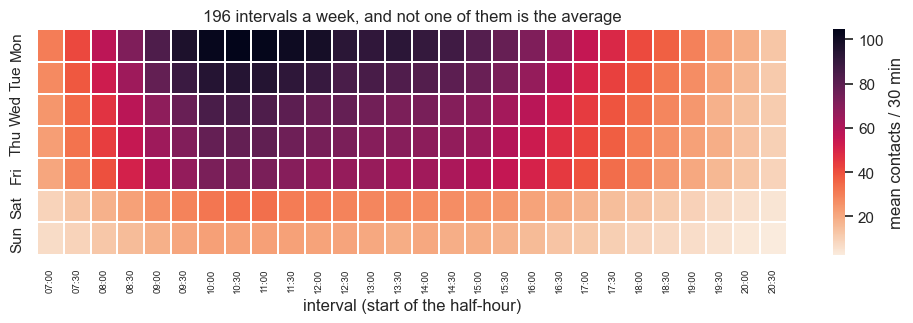

In [5]:
# FIG 1 -- the interval heatmap: day of week x half-hour, mean contacts
grid = iv.pivot_table(index="dow", columns="hour", values="contacts", aggfunc="mean")
grid.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
grid.columns = [f"{int(h):02d}:{'30' if h % 1 else '00'}" for h in grid.columns]

fig, ax = plt.subplots(figsize=(10, 3.4))
sns.heatmap(grid, cmap="rocket_r", ax=ax, cbar_kws={"label": "mean contacts / 30 min"},
            linewidths=0.3, linecolor="white")
ax.set_xlabel("interval (start of the half-hour)")
ax.set_ylabel("")
ax.set_title("196 intervals a week, and not one of them is the average")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()

mean_iv = iv.contacts.mean()
near = (abs(iv.contacts / mean_iv - 1) < 0.20).mean()
print(f"mean interval: {mean_iv:.1f} contacts; Monday 10:30 averages {grid.loc['Mon', '10:30']:.1f}, "
      f"Sunday 20:30 averages {grid.loc['Sun', '20:30']:.1f} "
      f"-> {grid.loc['Mon', '10:30'] / grid.loc['Sun', '20:30']:.0f}x")
print(f"share of intervals within +-20 % of the mean interval: {near:.1%}")

Read the picture the way a planner does, because it is the whole justification for the rest of the notebook.

The **mean interval is 45.9 contacts**. Monday 10:30 averages **104.5**; Sunday 20:30 averages **2.6** — a factor of **40** between two cells of the same grid. And only **14.9 %** of the two years' intervals land within ±20 % of that mean. A staffing plan built on "45.9 contacts per interval" is therefore a plan built for a situation that essentially never occurs: it will be catastrophically short on Monday morning and pay four people to watch a dead screen on Sunday evening. Both errors cost money, and only one of them is visible in the SLA report.

Notice the second plant in the table above too: the **password & how-to** share is **29.7 %** in the busiest decile of intervals but **44.9 %** in the quietest quartile. The cheap, self-service-shaped work is concentrated where there is time to spare. Keep that fact; §6 is built on it.

> 📌 **The unit of decision is the interval.** Daily and weekly totals are for finance. Anything that touches the SLA — staffing, deflection, forecast error, shrinkage — has to be argued half-hour by half-hour, because the queue empties and refills half-hour by half-hour.

## 2. Forecasting the arrivals — a prerequisite, not the point

You cannot staff a quarter you cannot forecast, so this section does NB 26's job at interval resolution and then gets out of the way. Same craft, same discipline: a baseline that must be beaten, a temporal holdout, and an error that ends up in a decision rather than in a slide.

- **Seasonal-naive** — this interval, one week ago. On a series with a hard weekly rhythm this baseline is *strong*, and any model that cannot beat it should be deleted.
- **Calendar-feature regression** — the same lag-feature reshaping NB 26 §2 drilled (`.shift()` a whole week to manufacture "the past as features"), plus what a planner genuinely knows in advance: day of week, interval-of-day, week of year, day of year, and the **published launch calendar** — a known future input, exactly like NB 26's promo flag.

Holdout: the **last eight weeks**, never touched during fitting.

In [6]:
f = iv[["contacts", "dow", "launch"]].copy()
f["slot"] = ((iv.hour - OPEN_FROM) * 2).astype(int)     # 0..27, the half-hour of the day
f["woy"] = f.index.isocalendar().week.astype(int)
f["doy"] = f.index.dayofyear
f["trend"] = np.arange(len(f))
f["lag_1w"] = f.contacts.shift(28 * 7)                  # same interval, last week
f["lag_2w"] = f.contacts.shift(28 * 14)
f = f.dropna()

HOLD = 28 * 7 * 8                                       # last 8 weeks of intervals
train, test = f.iloc[:-HOLD], f.iloc[-HOLD:]
FEATS = ["dow", "slot", "woy", "doy", "launch", "lag_1w", "lag_2w", "trend"]

model = HistGradientBoostingRegressor(max_iter=300, random_state=0)
model.fit(train[FEATS], train.contacts)
pred = model.predict(test[FEATS])

mae_naive = mean_absolute_error(test.contacts, test.lag_1w)
mae_model = mean_absolute_error(test.contacts, pred)
print(f"holdout: {len(test):,} intervals, {test.index.min():%Y-%m-%d} .. {test.index.max():%Y-%m-%d}")
print(f"  seasonal-naive        MAE {mae_naive:.2f} contacts/interval")
print(f"  calendar regression   MAE {mae_model:.2f} contacts/interval  "
      f"({1 - mae_model / mae_naive:.1%} better)")

wk_actual = test.contacts.resample("W").sum()
wk_pred = pd.Series(pred, index=test.index).resample("W").sum()
print("\nweekly totals, forecast vs actual (%):",
      ", ".join(f"{v:+.1f}" for v in ((wk_pred - wk_actual) / wk_actual * 100)))

# The error that becomes a staffing buffer: how much HIGHER than the forecast can
# an interval come in? Restrict to intervals that matter (>= 30 contacts) -- the
# tiny ones are pure Poisson noise and are never the binding constraint.
big = test.contacts >= 30
ratio = (test.contacts / np.clip(pred, 1, None))[big]
BUFFER = float(np.quantile(ratio, 0.90))
print(f"actual / forecast on the {big.sum():,} intervals with >= 30 contacts:")
print(f"  median {np.quantile(ratio, 0.50):.3f}   p90 {BUFFER:.3f}   p99 {np.quantile(ratio, 0.99):.3f}")
print(f"-> staffing every interval for its p90 volume means planning at +{BUFFER - 1:.1%}")

holdout: 1,568 intervals, 2025-11-06 .. 2025-12-31
  seasonal-naive        MAE 7.73 contacts/interval
  calendar regression   MAE 5.87 contacts/interval  (24.1% better)

weekly totals, forecast vs actual (%): -0.5, +0.6, +1.0, +0.2, +0.5, -1.0, -1.9, -2.6, -1.4
actual / forecast on the 1,013 intervals with >= 30 contacts:
  median 1.016   p90 1.221   p99 1.426
-> staffing every interval for its p90 volume means planning at +22.1%


The regression beats the baseline by **24.1 %** at interval level (MAE **5.87** vs **7.73** contacts), and its **weekly totals land within −2.6 % to +1.0 %** — which is the accuracy finance cares about and, notably, *not* the accuracy the SLA cares about. The SLA is decided inside the intervals.

That is what the second cell measures. On intervals that actually carry load, the p90 of *actual ÷ forecast* is **1.221** — one interval in ten arrives at least **22.1 %** above plan. A forecast is a **distribution**, and staffing to its centre means missing the SLA in roughly half of all intervals by construction. The honest planning question is therefore not "what is the forecast?" but "**what quantile of the forecast are we buying?**" — the same question NB 26 asked about safety stock and the newsvendor, with agents instead of pallets. Stretch C sizes that choice properly — and finds the answer is emphatically not the point forecast.

> 🧭 **Where this section stops.** Everything from here on uses the *realised* Q4 volumes, i.e. a perfect forecast. That is deliberate: it isolates the queueing lesson from the forecasting lesson. Every euro below is therefore a **best case**; the buffer is what stands between it and reality.

## 3. Erlang C from scratch — and a simulation to check it

Here is the sentence that costs contact centres the most money every year: *"we get 100 contacts an hour and a contact takes 6 minutes, so we need 10 agents."*

The arithmetic is right and the conclusion is wrong. 100 contacts × 6 minutes = 600 minutes of work per hour = **10 Erlangs** of **offered load**, and ten agents would indeed be exactly enough *if arrivals were perfectly evenly spaced and every call took exactly six minutes*. They aren't and it doesn't. Arrivals cluster; handle times scatter. With ten agents the queue grows without bound. The extra agents you hire on top of the offered load are not waste — they are **the product**: they are what converts a random arrival stream into an answered call.

**Offered load**, in Erlangs, is the dimensionless amount of work arriving per unit time:

$$A = \lambda \cdot \text{AHT}\qquad(\lambda \text{ in contacts per hour, AHT in hours})$$

For a 30-minute interval with $v$ contacts, $\lambda = 2v$. **Erlang C** then answers the only question that matters — with $n$ agents serving load $A$, what fraction of arrivals has to wait?

$$C(n, A) \;=\; \frac{\dfrac{A^n}{n!}\dfrac{n}{n-A}}{\sum_{k=0}^{n-1}\dfrac{A^k}{k!} + \dfrac{A^n}{n!}\dfrac{n}{n-A}}$$

Computed directly that formula overflows on any real centre ($A^{34}/34!$), so everyone in the industry computes it through the numerically harmless **Erlang B recursion** instead. From $C$ everything else follows in one line each:

$$P(\text{wait} > t) = C \cdot e^{-(n-A)t/\text{AHT}}, \qquad \text{SL}(t) = 1 - P(\text{wait} > t), \qquad \text{ASA} = \frac{C \cdot \text{AHT}}{n - A}$$

Fifteen lines of Python. Three assumptions worth naming out loud before we lean on it: **Poisson arrivals**, **exponential handle times**, **nobody hangs up and nobody is turned away**. §7 says what each of those costs.

In [7]:
def erlang_b(n, a):
    """Erlang B by the standard recursion -- no factorials, no overflow."""
    inv = 1.0
    for i in range(1, int(n) + 1):
        inv = 1.0 + inv * i / a
    return 1.0 / inv


def erlang_c(n, a):
    """P(an arriving contact has to wait at all), n agents, offered load a Erlangs."""
    b = erlang_b(n, a)
    return b / (1 - (a / n) * (1 - b))


def offered_load(contacts, aht_s):
    """Erlangs offered by `contacts` arrivals in a 30-minute interval."""
    return contacts * 2 * aht_s / 3600


def service_level(n, a, aht_s, t=SLA_SECONDS):
    """P(answered within t seconds)."""
    if a <= 0:
        return 1.0
    if n <= a:
        return 0.0                      # unstable queue: the backlog never clears
    return 1 - erlang_c(n, a) * math.exp(-(n - a) * t / aht_s)


def asa(n, a, aht_s):
    """Average speed of answer, seconds (averaged over ALL contacts, not just waiters)."""
    if a <= 0:
        return 0.0
    if n <= a:
        return float("inf")
    return erlang_c(n, a) * aht_s / (n - a)


def agents_required(a, aht_s, target=SLA_TARGET, t=SLA_SECONDS):
    """Smallest agent count that meets the service-level target."""
    if a <= 0:
        return 1
    n = int(a) + 1                      # n must exceed A or the queue is unstable
    while service_level(n, a, aht_s, t) < target:
        n += 1
    return n

In [8]:
# One interval, worked end to end: 87 contacts in 30 minutes at the pooled AHT.
v_demo = 87
a_demo = offered_load(v_demo, AHT_S)
print(f"{v_demo} contacts / 30 min at AHT {AHT_S / 60:.2f} min "
      f"-> offered load {a_demo:.2f} Erlangs")
rows = []
for n in range(int(a_demo) + 1, int(a_demo) + 11):
    rows.append({"agents": n, "occupancy": a_demo / n, "P(wait)": erlang_c(n, a_demo),
                 "ASA (s)": asa(n, a_demo, AHT_S),
                 "SL 20s": service_level(n, a_demo, AHT_S)})
print(pd.DataFrame(rows).set_index("agents").round(3).to_string())
print(f"\nagents required for {SLA_TARGET:.0%}/{SLA_SECONDS:.0f}s: "
      f"{agents_required(a_demo, AHT_S)}   (offered load was only {a_demo:.1f})")

87 contacts / 30 min at AHT 6.90 min -> offered load 20.00 Erlangs
        occupancy  P(wait)  ASA (s)  SL 20s
agents                                     
21          0.953    0.761  316.081   0.274
22          0.909    0.568  117.821   0.484
23          0.870    0.416   57.475   0.640
24          0.833    0.298   30.901   0.754
25          0.800    0.209   17.341   0.836
26          0.769    0.144    9.910   0.893
27          0.741    0.096    5.691   0.931
28          0.714    0.063    3.257   0.957
29          0.690    0.040    1.847   0.974
30          0.667    0.025    1.035   0.985

agents required for 80%/20s: 25   (offered load was only 20.0)


In [9]:
# 🔬 Does the formula tell the truth? Simulate the queue and find out.
def simulate_queue(n, a, aht_s, n_arrivals=60_000, seed=0, warmup=2_000):
    """Plain M/M/c: exponential gaps, exponential service, first free agent takes the call."""
    rng = np.random.default_rng(seed)
    arrive = np.cumsum(rng.exponential(aht_s / a, n_arrivals))   # rate lambda = a / AHT
    service = rng.exponential(aht_s, n_arrivals)
    free = np.zeros(n)                                          # when each agent frees up
    wait = np.empty(n_arrivals)
    for i in range(n_arrivals):
        j = int(np.argmin(free))
        start = arrive[i] if arrive[i] > free[j] else free[j]
        wait[i] = start - arrive[i]
        free[j] = start + service[i]
    return wait[warmup:]                                        # discard the empty-system warm-up


A_CHK, N_CHK = 20.0, 25
w = simulate_queue(N_CHK, A_CHK, AHT_S)
print(f"A = {A_CHK} Erlangs, n = {N_CHK} agents, AHT = {AHT_S:.0f}s\n")
print(f"{'':<12}{'Erlang C':>10}{'simulation':>13}")
print(f"{'P(wait)':<12}{erlang_c(N_CHK, A_CHK):>10.3f}{(w > 1e-9).mean():>13.3f}")
print(f"{'SL 20s':<12}{service_level(N_CHK, A_CHK, AHT_S):>10.3f}{(w <= 20).mean():>13.3f}")
print(f"{'ASA (s)':<12}{asa(N_CHK, A_CHK, AHT_S):>10.1f}{w.mean():>13.1f}")

A = 20.0 Erlangs, n = 25 agents, AHT = 414s

              Erlang C   simulation
P(wait)          0.209        0.199
SL 20s           0.836        0.847
ASA (s)           17.3         16.1


The formula and the simulation agree to the second decimal — **P(wait) 0.209 vs 0.199**, **SL 0.836 vs 0.847**, **ASA 17.3 s vs 16.1 s** (the residual is Monte-Carlo noise on 58,000 arrivals). Fifteen lines of algebra reproduce a queue you had to simulate to check. That is worth doing once in your life, for two reasons: you now believe the formula, and you now own a simulator — which is exactly the tool §7 says you must reach for when the formula's assumptions break.

And look at the worked interval before it. Offered load **20.0 Erlangs**; agents required for 80/20: **25**. Not 20, not 21 — **25**. Those extra five agent-slots are the insurance premium, and no amount of management enthusiasm removes them. Note also how the table turns: the step from 21 agents to 25 lifts the service level from **27.4 %** to **83.6 %**, while the step from 27 to 29 — the same two extra people — manages only **93.1 % → 97.4 %**. **Every agent you add buys less than the one before.** That is the shape the next section is about.

---

### ✋ Quick exercise (~2 min) — offered load by hand

A Monday 09:30 interval is forecast at **96 contacts**, and this interval's contacts are unusually heavy: **AHT 7.5 minutes**.

1. What is the offered load in **Erlangs**?
2. What is the largest agent count that could *never* keep up, no matter how the queue is managed?
3. How many agents does 80/20 actually need — and what is the gap, in people and in percent, between that and your answer to (2)?

In [10]:
# ✍️ Your turn 👇
# lambda is per HOUR, so a 30-minute interval contributes 2 x its contacts.
v, aht_min = 96, 7.5
# a = offered_load(...)             # in Erlangs
# floor_agents = ...                # anything <= A is an unstable queue
# needed = agents_required(...)

<details>
<summary>✅ <b>Solution</b></summary>

```python
v, aht_min = 96, 7.5
a = offered_load(v, aht_min * 60)
floor_agents = int(a)
needed = agents_required(a, aht_min * 60)
print(f"offered load          : {a:.1f} Erlangs")
print(f"never enough          : {floor_agents} agents (queue grows without bound)")
print(f"required for 80/20    : {needed} agents")
print(f"the insurance premium : +{needed - a:.1f} agents = +{(needed - a) / a:.0%}")
```

$A = 2 \times 96 \times 7.5/60 = \textbf{24.0 Erlangs}$ — twenty-four agent-hours of work arriving per hour. **Twenty-four agents are not enough**: at $n = A$ the queue is exactly critical and the backlog grows without bound, which is why `agents_required` starts its search at $\lfloor A \rfloor + 1$. The 80/20 answer is **29** — a **+21 % premium** over the raw work. Every planning conversation you will ever have starts by getting this number, and roughly every second one starts by getting it wrong: the linear rule would have said 24 and the SLA report would have said 0 %.
</details>

## 4. What the formula teaches: a stepped curve and a cliff

Two properties of Erlang C decide almost everything an operations team argues about. Both are visible in one table and one chart.

**(1) The staffing curve is not a line through the origin.** Required agents = offered load **plus a buffer**, and that buffer grows roughly like $\sqrt{A}$ — so it is proportionally enormous for a small interval and modest for a big one. This cuts two ways at once, and you need both directions in your head:

- *Downward* (this is §6's engine): a big centre pools variability. Cut the volume by 30 % and you do **not** cut agents by 30 %.
- *Upward*: because agents are **integers**, the curve is a **staircase**. In a big interval one more agent is a rounding error; in an interval staffed by seven, one more agent is **+14 %** — and a 5 % volume miss is quite enough to trigger it.

**(2) It is a curve, not a slope.** The marginal agent's contribution to service level collapses as occupancy falls, which is why "just add people" and "just push utilisation" are both wrong in the specific ways §4.2 measures.

We build the curve on the profile that matters: an average **Monday in Q4** — the quarter we are about to staff.

In [11]:
q = iv.loc["2025-10-01":"2025-12-31"].copy()            # the quarter we must staff
q["A"] = offered_load(q.contacts, q.aht_s)
weeks_q = len(q) / 28 / 7

mon = q[q.dow == 0].groupby("hour").agg(vol=("contacts", "mean"), aht=("aht_s", "mean"))
rows = []
for h, r in mon.iterrows():
    a = offered_load(r.vol, r.aht)
    n = agents_required(a, r.aht)
    n_up = agents_required(offered_load(r.vol * 1.05, r.aht), r.aht)     # +5 % volume
    n_dn = agents_required(offered_load(r.vol * 0.70, r.aht), r.aht)     # -30 % volume
    rows.append({"hour": h, "contacts": r.vol, "A": a, "agents": n,
                 "occupancy": a / n, "buffer_%": (n - a) / a,
                 "n_+5%vol": n_up, "agents_+%": (n_up - n) / n,
                 "n_-30%vol": n_dn, "agents_-%": (n - n_dn) / n})
curve = pd.DataFrame(rows)
print(curve.round(3).to_string(index=False))

 hour  contacts      A  agents  occupancy  buffer_%  n_+5%vol  agents_+%  n_-30%vol  agents_-%
  7.0    34.154  7.633      11      0.694     0.441        12      0.091          8      0.273
  7.5    48.692 10.506      14      0.750     0.333        15      0.071         11      0.214
  8.0    60.154 13.669      18      0.759     0.317        19      0.056         13      0.278
  8.5    80.692 19.277      24      0.803     0.245        25      0.042         18      0.250
  9.0    89.385 21.688      27      0.803     0.245        28      0.037         20      0.259
  9.5   106.231 25.756      31      0.831     0.204        33      0.065         23      0.258
 10.0   112.231 27.919      34      0.821     0.218        35      0.029         25      0.265
 10.5   111.769 27.889      34      0.820     0.219        35      0.029         25      0.265
 11.0   107.538 26.168      32      0.818     0.223        33      0.031         23      0.281
 11.5   111.154 27.751      33      0.841     0.18

20:00  A  4.46 ->  7 agents  (+57% buffer, occupancy 64%)
10:00  A 27.92 -> 34 agents  (+22% buffer, occupancy 82%)

+5 % volume: needs another agent in 23 of 28 intervals; median +4.0%, max +14.3% (at 20.0h)
-30 % volume: agents fall by only 26.2% at the median (peak interval 26.5%, quietest 20.0%)


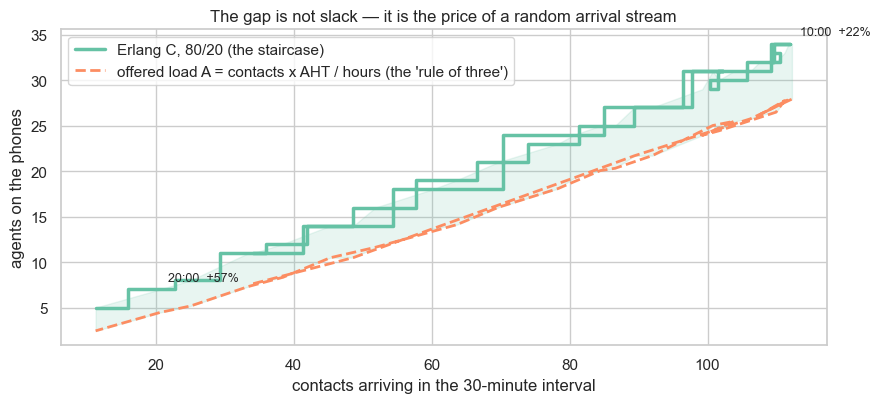

In [12]:
# FIG 2 -- the staffing staircase against the rule of three
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.step(curve.contacts, curve.agents, where="mid", color="#66c2a5", lw=2.5,
        label="Erlang C, 80/20 (the staircase)")
ax.plot(curve.contacts, curve.A, color="#fc8d62", lw=2, ls="--",
        label="offered load A = contacts x AHT / hours (the 'rule of three')")
ax.fill_between(curve.contacts.sort_values(),
                curve.sort_values("contacts").A,
                curve.sort_values("contacts").agents,
                color="#66c2a5", alpha=0.15)
for h in (20.0, 10.0):
    r = curve[curve.hour == h].iloc[0]
    ax.annotate(f"{int(h):02d}:00  +{(r.agents - r.A) / r.A:.0%}",
                (r.contacts, r.agents), textcoords="offset points", xytext=(6, 6), fontsize=9)
ax.set_xlabel("contacts arriving in the 30-minute interval")
ax.set_ylabel("agents on the phones")
ax.set_title("The gap is not slack — it is the price of a random arrival stream")
ax.legend(loc="upper left")
plt.tight_layout()

sm, bg = curve[curve.hour == 20.0].iloc[0], curve[curve.hour == 10.0].iloc[0]
print(f"20:00  A {sm.A:5.2f} -> {sm.agents:2.0f} agents  (+{(sm.agents - sm.A) / sm.A:.0%} buffer, "
      f"occupancy {sm.occupancy:.0%})")
print(f"10:00  A {bg.A:5.2f} -> {bg.agents:2.0f} agents  (+{(bg.agents - bg.A) / bg.A:.0%} buffer, "
      f"occupancy {bg.occupancy:.0%})")
print(f"\n+5 % volume: needs another agent in {(curve['n_+5%vol'] > curve.agents).sum()} of "
      f"{len(curve)} intervals; median +{curve['agents_+%'].median():.1%}, "
      f"max +{curve['agents_+%'].max():.1%} (at "
      f"{curve.hour[curve['agents_+%'].idxmax()]:.1f}h)")
print(f"-30 % volume: agents fall by only {curve['agents_-%'].median():.1%} at the median "
      f"(peak interval {curve.loc[curve.contacts.idxmax(), 'agents_-%']:.1%}, "
      f"quietest {curve.loc[curve.contacts.idxmin(), 'agents_-%']:.1%})")

Three numbers off that chart, each of which ends an argument you will otherwise have repeatedly:

1. **The premium is a scale effect.** At 20:00 the offered load is **4.46 Erlangs** and 80/20 needs **7 agents** — a **57 %** buffer, and the team runs at **64 %** occupancy. At 10:00 the load is **27.92 Erlangs** and 80/20 needs **34** — a **22 %** buffer at **82 %** occupancy. Same SLA, same formula, wildly different efficiency. This is why small sites, small language queues and small skill groups are structurally expensive, and why merging two half-size queues into one saves real money (Stretch B).
2. **+5 % volume costs more than +5 % agents, and sometimes a lot more.** Twenty-three of the twenty-eight intervals need another body; the median cost is **+4.0 %** but the 20:00 interval goes **7 → 8 agents = +14.3 %**. On a staircase, a small step sideways can be a whole stair. That is the honest form of the folk claim that "five percent more volume costs fifteen percent more agents" — it is not true on average, it is true *where the teams are small*, which happens to be most of the intervals in a seven-day roster.
3. **And the same staircase runs the other way**, which is the fact §6 is built on: take **30 %** of the volume away and agents fall by only **26.2 %** at the median — and by **20.0 %** in the quietest interval, because the buffer does not shrink with the work. Deflection removes contacts; it does not remove insurance.

---

### ✋ Quick exercise (~2 min) — read the staircase

Using `curve` (and `agents_required` if you want to check yourself):

1. Which interval on this Monday pays the **highest** percentage buffer over its offered load, and which pays the **lowest**? Roughly what is the ratio between them?
2. HelpDeskAI is considering closing the last hour (20:00 and 20:30) and pushing that volume to the next morning. How many **agent-hours** per Monday does that free up — and how does that compare with the contacts involved as a share of the day?

In [13]:
# ✍️ Your turn 👇
# curve has columns: hour, contacts, A, agents, occupancy, buffer_%, ...
# (1) curve.loc[curve["buffer_%"].idxmax()] ...
# (2) each interval is half an hour, so agent-hours = agents * 0.5

<details>
<summary>✅ <b>Solution</b></summary>

```python
worst = curve.loc[curve["buffer_%"].idxmax()]
best = curve.loc[curve["buffer_%"].idxmin()]
print(f"highest buffer: {worst.hour:.1f}h  A {worst.A:.2f} -> {worst.agents:.0f} agents "
      f"(+{worst['buffer_%']:.0%})")
print(f"lowest  buffer: {best.hour:.1f}h  A {best.A:.2f} -> {best.agents:.0f} agents "
      f"(+{best['buffer_%']:.0%})")
print(f"ratio: {worst['buffer_%'] / best['buffer_%']:.1f}x")

last = curve[curve.hour >= 20.0]
print(f"\nclosing 20:00-21:00 frees {last.agents.sum() * 0.5:.1f} agent-hours per Monday "
      f"({last.agents.sum() * 0.5 / (curve.agents.sum() * 0.5):.1%} of the day's agent-hours) "
      f"and defers {last.contacts.sum():.0f} contacts "
      f"({last.contacts.sum() / curve.contacts.sum():.1%} of the day's volume)")
```

The 20:30 interval pays a **104 %** buffer — it needs five agents for 2.45 Erlangs of work — while 11:30 pays **19 %**. A **5.5×** spread, driven by nothing but size. The closing question is the practical pay-off: the last hour carries **1.5 %** of Monday's contacts but **1.9 %** of Monday's agent-hours — a quarter more staffing per contact than the day's average, because those two intervals are the least efficient on the whole grid. *Every* proposal to trim opening hours, add a language queue, or split a team should be argued on this asymmetry — the tail intervals always cost more per contact than the peak does, and the peak is the only place anybody ever looks.
</details>

### 4.2 The occupancy trap

**Occupancy** is the share of logged-in time an agent spends actually handling contacts, $\rho = A/n$. It is the number every finance review asks to see go up, and the number that will destroy your operation if it does.

The reason is the $1/(1-\rho)$ that lives inside every queue: waiting time does not rise smoothly with utilisation, it rises **hyperbolically**. Hold the offered load at 20 Erlangs and walk the agent count down.

offered load fixed at A = 20 Erlangs:
        occupancy  P(wait)  ASA (s)  SL 20s
agents                                     
21          0.952    0.761  314.798   0.275
22          0.909    0.568  117.518   0.484
23          0.870    0.416   57.352   0.640
24          0.833    0.298   30.840   0.754
25          0.800    0.209   17.308   0.836
26          0.769    0.143    9.891   0.893
27          0.741    0.096    5.680   0.932
28          0.714    0.063    3.250   0.957
29          0.690    0.040    1.843   0.974


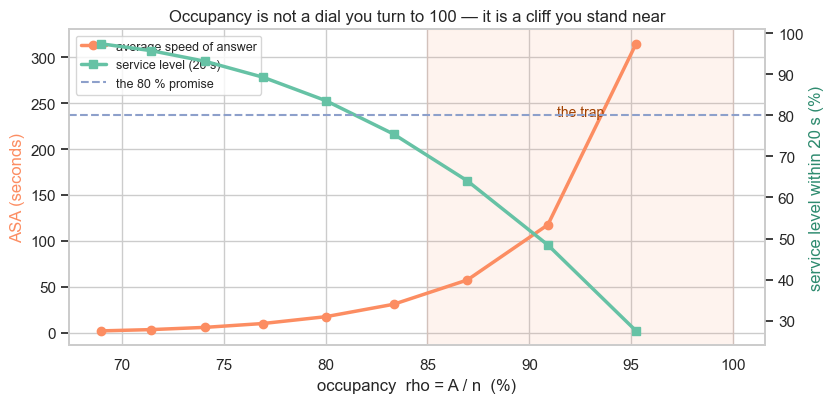

In [14]:
cliff = pd.DataFrame([
    {"agents": n, "occupancy": 20.0 / n, "P(wait)": erlang_c(n, 20.0),
     "ASA (s)": asa(n, 20.0, AHT_S), "SL 20s": service_level(n, 20.0, AHT_S)}
    for n in range(21, 30)]).set_index("agents")
print("offered load fixed at A = 20 Erlangs:")
print(cliff.round(3).to_string())

# FIG 3 -- the cliff
fig, ax1 = plt.subplots(figsize=(8.5, 4.2))
ax1.plot(cliff.occupancy * 100, cliff["ASA (s)"], "-o", color="#fc8d62", lw=2.5,
         label="average speed of answer")
ax1.set_xlabel("occupancy  rho = A / n  (%)")
ax1.set_ylabel("ASA (seconds)", color="#fc8d62")
ax1.axvspan(85, 100, color="#fc8d62", alpha=0.10)
ax1.text(92.5, cliff["ASA (s)"].max() * 0.75, "the trap", ha="center", fontsize=10, color="#a04000")
ax2 = ax1.twinx()
ax2.plot(cliff.occupancy * 100, cliff["SL 20s"] * 100, "-s", color="#66c2a5", lw=2.5,
         label="service level (20 s)")
ax2.axhline(SLA_TARGET * 100, color="#8da0cb", ls="--", lw=1.5, label="the 80 % promise")
ax2.set_ylabel("service level within 20 s (%)", color="#2e8b6f")
ax2.grid(False)
ax1.set_title("Occupancy is not a dial you turn to 100 — it is a cliff you stand near")
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=9)
plt.tight_layout()

Walk the table from the bottom up and watch the operation die.

At **80 %** occupancy (25 agents) the queue answers **83.6 %** within 20 seconds and the average wait is **17 seconds** — comfortably inside the promise. Push to **87 %** (23 agents, a saving of two people) and the SLA falls to **64.0 %** while the average wait **triples to 57 seconds**. Push to **90.9 %** (22 agents) and it is **48.4 %** and **118 seconds**. At **95.2 %** — an occupancy figure that looks *excellent* on a slide — the service level is **27.5 %** and the average wait is **five and a quarter minutes**. Three agents, a 15-point occupancy "improvement", and the entire customer promise.

> ⚠️ **"Run everyone at 100 % utilisation" is an operational death wish.** At $\rho = 1$ the queue is critical: arrivals exactly equal capacity, so any burst — and a Poisson stream is *nothing but* bursts — creates a backlog with no slack left to work it off. The formula reports an infinite wait, and the floor reports a queue that never clears, agents who never breathe, handle times that inflate under pressure (making the load worse), and an attrition problem that arrives about six weeks later. Roughly **85 %** is the practical ceiling for a voice queue, and small teams cannot reach even that (see the 20:00 interval: **64 %**, and that is *correct*).

This is also the deepest reason the flat plan of §5 fails. It does not merely mis-allocate people; it parks the busy intervals on the wrong side of this cliff, where the arithmetic stops being linear and starts being vertical.

---

### ✋ Quick exercise (~2 min) — reading the cliff

The operations director proposes a productivity target: **"every interval must run at 88 % occupancy or better."** Using `cliff` and the Erlang helpers:

1. At A = 20 Erlangs, what service level does an 88 %-occupancy interval deliver? Is the target compatible with the 80/20 SLA?
2. Now do it for a *small* interval — A = 4.5 Erlangs (the 20:00 interval). How many agents would 88 % occupancy imply, and what happens?
3. State in one sentence what the occupancy target should be replaced by.

In [15]:
# ✍️ Your turn 👇
# (1) which row of `cliff` is closest to 88 % occupancy? read SL 20s off it
# (2) n = A / 0.88, rounded -- then service_level(n, 4.5, AHT_S)
# (3) a sentence, as a comment

<details>
<summary>✅ <b>Solution</b></summary>

```python
row = cliff.iloc[(cliff.occupancy - 0.88).abs().argmin()]
print(f"A=20: {row.name} agents -> occupancy {row.occupancy:.1%}, "
      f"SL {row['SL 20s']:.1%}, ASA {row['ASA (s)']:.0f}s")

a_small = 4.5
n_small = max(int(np.ceil(a_small / 0.88)), int(a_small) + 1)
print(f"A=4.5: 88% occupancy implies {a_small / 0.88:.1f} -> {n_small} agents, "
      f"SL {service_level(n_small, a_small, AHT_S):.1%}, "
      f"occupancy {a_small / n_small:.1%} (the integer floor makes 88% unreachable)")
print(f"       80/20 actually needs {agents_required(a_small, AHT_S)} agents "
      f"at {a_small / agents_required(a_small, AHT_S):.0%} occupancy")
```

At A = 20, the closest thing to 88 % occupancy is **23 agents (87.0 %)** — and it delivers **64.0 %** service level against an **80 %** promise. The target and the SLA are **mutually exclusive**; one of the two is going to be quietly abandoned, and it will not be the one finance measures. On the small interval it is worse than wrong, it is *incoherent*: 4.5/0.88 = 5.1 → 6 agents, which lands at **75 %** occupancy anyway (the integer floor makes 88 % unreachable) and delivers a **60.8 %** service level; the 80/20 requirement is **7 agents at 64 %** occupancy. Occupancy is an **outcome** of size and service level, not an input. The right target is the **service level**, with occupancy *reported* so that anything above ~85 % raises an alarm — the opposite of a KPI.
</details>

## 5. The money: shrinkage, the cost of waiting, and the service level to buy

Now we turn the formula into a quarter's plan and a quarter's bill. Q4 2025 — the quarter HelpDeskAI is staffing — and three steps, in the order that catches out real planning teams.

**Step 1: size every interval.** `agents_required` over all 2,576 intervals of the quarter. That yields **productive** agent-hours: bums on seats, headsets on, ready for the next contact.

**Step 2: apply shrinkage.** This is the classic staffing-plan error, and it is embarrassingly simple. An agent rostered for eight hours does not spend eight hours available. Breaks, lunch, team meetings, coaching, training, sickness, holiday, system outages, admin — in this industry that is **25–35 % of paid time**, and it means the plan must roster

$$\text{paid heads} = \frac{\text{required agents}}{1 - \text{shrinkage}}$$

Skip this line and the roster is 30 % short *everywhere*, every day, for the whole quarter. Nobody notices in the model; everybody notices on the floor.

**Step 3: price the waiting.** Agents cost €38 an hour. But the *alternative* to an agent is not free, and quantifying that is what turns this from an engineering exercise into a business decision.

In [16]:
q["req"] = [agents_required(a, s) for a, s in zip(q.A, q.aht_s)]
productive_h = q.req.sum() * 0.5
paid_h = productive_h / (1 - SHRINKAGE)
work_h = q.work_min.sum() / 60
FTE = paid_h / weeks_q / 40                                   # a 40-hour contract

print(f"Q4 2025: {q.contacts.sum():,} contacts over {weeks_q:.2f} weeks "
      f"({len(q):,} intervals), {work_h:,.0f} hours of actual talk time")
print(f"\ninterval plan at {SLA_TARGET:.0%}/{SLA_SECONDS:.0f}s")
print(f"  productive agent-hours : {productive_h:>10,.0f}   (occupancy {work_h / productive_h:.1%})")
print(f"  paid agent-hours       : {paid_h:>10,.0f}   (shrinkage {SHRINKAGE:.0%})")
print(f"  headcount              : {FTE:>10.1f} FTE")
print(f"  quarterly cost         : EUR {paid_h * AGENT_HOUR_EUR:>10,.0f}")
print(f"\nthe shrinkage line alone: {FTE - productive_h / weeks_q / 40:.1f} FTE and "
      f"EUR {(paid_h - productive_h) * AGENT_HOUR_EUR:,.0f} per quarter")

Q4 2025: 125,632 contacts over 13.14 weeks (2,576 intervals), 14,494 hours of actual talk time

interval plan at 80%/20s
  productive agent-hours :     19,437   (occupancy 74.6%)
  paid agent-hours       :     27,767   (shrinkage 30%)
  headcount              :       52.8 FTE
  quarterly cost         : EUR  1,055,151

the shrinkage line alone: 15.8 FTE and EUR 316,545 per quarter


There is the first headline number: **52.8 FTE and €1,055,151** for the quarter, against **14,494 hours** of actual talk time. The floor runs at **74.6 % occupancy** — which, after §4.2, you now read as *healthy*, not as slack.

And notice what shrinkage did. Forget that one line and the plan says **37.0 FTE**; include it and it says **52.8**. That is a **15.8-FTE, €316,545-per-quarter** difference produced by a single division — and it is the most common error in staffing plans written by people who are otherwise excellent at arithmetic. Productive hours and paid hours are different currencies, and the roster is denominated in the second one.

---

### ✋ Quick exercise (~2 min) — shrinkage on one interval

Take Q4's busiest interval: **2025-11-24 at 10:00**, 139 contacts, offered load 36.3 Erlangs, **43 agents** required for 80/20.

1. How many people must be *rostered* for that half-hour at 30 % shrinkage?
2. What does that half-hour cost at €38 per paid agent-hour?
3. If the shrinkage assumption is wrong and the true figure is **35 %**, how many extra people is that in this interval — and how would you find out which number is right?

In [17]:
# ✍️ Your turn 👇
required = 43
# rostered = required / (1 - SHRINKAGE)   -> round UP, you cannot roster 0.4 of a person
# cost = rostered * 0.5 * AGENT_HOUR_EUR

<details>
<summary>✅ <b>Solution</b></summary>

```python
required = 43
for sh in (SHRINKAGE, 0.35):
    rostered = math.ceil(required / (1 - sh))
    print(f"shrinkage {sh:.0%}: roster {required / (1 - sh):5.1f} -> {rostered} people, "
          f"half-hour cost EUR {rostered * 0.5 * AGENT_HOUR_EUR:,.0f}")
print(f"\nthe 5-point shrinkage error costs "
      f"{math.ceil(required / 0.65) - math.ceil(required / 0.70)} people in this one interval")
```

Forty-three on the phones needs **61.4 → 62 people rostered**, costing **€1,178** for that single half-hour. At 35 % shrinkage it is **67** — **five more people**, in one interval, from a five-point assumption. Multiply by 2,576 intervals and shrinkage is the single largest unforced number in the plan.

Which is why the answer to (3) is the important part: **you measure it, you do not assume it.** Shrinkage is `1 − (hours logged in and available ÷ hours paid)`, and every workforce-management system on the market reports it. Take last quarter's actuals, split them by day of week and interval (shrinkage is *not* flat — it peaks at lunchtime and on Fridays, exactly when volume does), and use those. A planner who quotes an industry benchmark instead of their own telephony export is guessing with two significant figures.
</details>

### 5.2 What is a wait worth? — and the service level to buy

The contract says 80/20. Where did 80 come from? Almost always: a competitor's slide, a procurement negotiation, or a round number somebody liked. Never from the cost of the alternative. So let's do the thing this module always does — **price the alternative and let the economics choose the threshold**.

A contact that waits too long is **abandoned**, and an abandoned contact costs HelpDeskAI in three ways:

- it usually **comes back** — a repeat contact is a second full handle time, at the same €38 loaded hour;
- it **raises churn** by a small amount on a subscriber worth roughly €1,900 of remaining margin (NB 23's CLV table is where that number lives);
- a fraction end in a **goodwill credit** or an escalation to a manager.

For abandonment itself we need one thing Erlang C does not have: **patience**. Model it as exponential with a 90-second mean — a contact abandons if its patience runs out before an agent frees up — which gives, for the fraction of contacts that wait at all,

$$P(\text{abandon}) \;=\; C(n,A)\cdot\frac{\text{AHT}}{\text{AHT} + \theta\,(n-A)}$$

That is a step towards **Erlang A**, the version of the formula that knows customers hang up (Stretch A builds the real thing). Then sweep the service-level target and add up the bill.

cost of one abandoned contact: EUR 3.74 repeat handling + EUR 9.50 churn risk + EUR 2.00 goodwill = EUR 15.24



           FTE  abandon %  labour EUR  abandon EUR   total EUR
SL target                                                     
0.60      48.2       23.0   961,916.0    439,562.0 1,401,478.0
0.70      50.1       16.2 1,001,490.0    310,144.0 1,311,634.0
0.75      51.4       12.9 1,026,489.0    248,014.0 1,274,502.0
0.80      52.8       10.0 1,055,151.0    192,001.0 1,247,152.0
0.84      54.3        7.7 1,083,923.0    147,493.0 1,231,416.0
0.86      55.1        6.6 1,100,371.0    126,741.0 1,227,113.0
0.88      56.0        5.6 1,118,394.0    106,702.0 1,225,096.0
0.90      57.0        4.6 1,139,674.0     87,164.0 1,226,838.0
0.92      58.4        3.5 1,166,166.0     67,605.0 1,233,771.0
0.95      61.0        2.1 1,218,253.0     40,389.0 1,258,642.0
0.98      65.7        0.8 1,313,117.0     15,080.0 1,328,197.0

cost-optimal service level: 88%
optimum 88%: EUR 1,225,096 total  (56.0 FTE, 5.6% abandoned)
contracted 80 %  : EUR 1,247,152  -> EUR 22,056 worse
'best in class' 98 %: EUR 1,328,

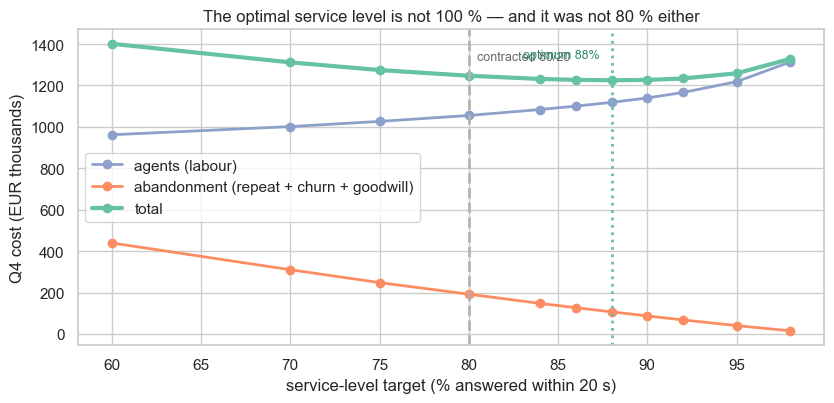

In [18]:
PATIENCE_S = 90.0            # mean patience before abandoning, seconds
REPEAT_RATE = 0.60           # abandoned contacts that come back
CHURN_UPLIFT = 0.005         # extra churn probability caused by a bad wait
AVG_CLV = 1_900.0            # remaining margin of a HelpDeskAI subscriber (NB 23)
GOODWILL_RATE, GOODWILL_EUR = 0.05, 40.0


def p_abandon(n, a, aht_s, theta=PATIENCE_S):
    if a <= 0:
        return 0.0
    if n <= a:
        return 1.0
    return erlang_c(n, a) * aht_s / (aht_s + theta * (n - a))


cost_repeat = REPEAT_RATE * AHT_S / 3600 * AGENT_HOUR_EUR / (1 - SHRINKAGE)
cost_churn = CHURN_UPLIFT * AVG_CLV
cost_goodwill = GOODWILL_RATE * GOODWILL_EUR
ABANDON_EUR = cost_repeat + cost_churn + cost_goodwill
print(f"cost of one abandoned contact: EUR {cost_repeat:.2f} repeat handling "
      f"+ EUR {cost_churn:.2f} churn risk + EUR {cost_goodwill:.2f} goodwill "
      f"= EUR {ABANDON_EUR:.2f}")


def price_plan(agents):
    """Labour + abandonment cost of a staffing vector over the quarter."""
    labour = sum(agents) * 0.5 / (1 - SHRINKAGE) * AGENT_HOUR_EUR
    lost = sum(v * p_abandon(n, a, s)
               for n, a, s, v in zip(agents, q.A, q.aht_s, q.contacts))
    return labour, lost * ABANDON_EUR, lost


rows = []
for tgt in [0.60, 0.70, 0.75, 0.80, 0.84, 0.86, 0.88, 0.90, 0.92, 0.95, 0.98]:
    ns = [agents_required(a, s, tgt) for a, s in zip(q.A, q.aht_s)]
    labour, lost_eur, lost_n = price_plan(ns)
    rows.append({"SL target": tgt, "FTE": sum(ns) * 0.5 / (1 - SHRINKAGE) / weeks_q / 40,
                 "abandon rate": lost_n / q.contacts.sum(), "labour EUR": labour,
                 "abandon EUR": lost_eur, "total EUR": labour + lost_eur})
sl_sweep = pd.DataFrame(rows).set_index("SL target")
show = sl_sweep.copy()
show["FTE"] = show.FTE.round(1)
show["abandon rate"] = (show["abandon rate"] * 100).round(1)
for c in ["labour EUR", "abandon EUR", "total EUR"]:
    show[c] = show[c].round(0)
show = show.rename(columns={"abandon rate": "abandon %"})
print()
print(show.to_string(float_format=lambda x: f"{x:,.1f}"))
best_sl = sl_sweep["total EUR"].idxmin()
print(f"\ncost-optimal service level: {best_sl:.0%}")

# FIG 4 -- the U that decides the SLA
fig, ax = plt.subplots(figsize=(8.5, 4.2))
x = sl_sweep.index * 100
ax.plot(x, sl_sweep["labour EUR"] / 1e3, "-o", color="#8da0cb", lw=2, label="agents (labour)")
ax.plot(x, sl_sweep["abandon EUR"] / 1e3, "-o", color="#fc8d62", lw=2,
        label="abandonment (repeat + churn + goodwill)")
ax.plot(x, sl_sweep["total EUR"] / 1e3, "-o", color="#66c2a5", lw=3, label="total")
ax.axvline(best_sl * 100, color="#66c2a5", ls=":", lw=2)
ax.axvline(SLA_TARGET * 100, color="#b3b3b3", ls="--", lw=2)
ax.annotate("contracted 80/20", (SLA_TARGET * 100, sl_sweep["total EUR"].max() / 1e3),
            textcoords="offset points", xytext=(6, -12), fontsize=9, color="#666666")
ax.annotate(f"optimum {best_sl:.0%}", (best_sl * 100, sl_sweep["total EUR"].min() / 1e3),
            textcoords="offset points", xytext=(-64, 16), fontsize=9, color="#2e8b6f")
ax.set_xlabel("service-level target (% answered within 20 s)")
ax.set_ylabel("Q4 cost (EUR thousands)")
ax.set_title("The optimal service level is not 100 % — and it was not 80 % either")
ax.legend()
plt.tight_layout()

t_opt, t_80, t_98 = (sl_sweep.loc[best_sl, "total EUR"], sl_sweep.loc[0.80, "total EUR"],
                     sl_sweep.loc[0.98, "total EUR"])
print(f"optimum {best_sl:.0%}: EUR {t_opt:,.0f} total  "
      f"({sl_sweep.loc[best_sl, 'FTE']:.1f} FTE, {sl_sweep.loc[best_sl, 'abandon rate']:.1%} abandoned)")
print(f"contracted 80 %  : EUR {t_80:,.0f}  -> EUR {t_80 - t_opt:,.0f} worse")
print(f"'best in class' 98 %: EUR {t_98:,.0f}  -> EUR {t_98 - t_opt:,.0f} worse")

The curve is a **U**, and every U in this module is the same U.

The cost-minimising target is **88 %**, not 80 % and emphatically not 100 %. Under-serve and the abandonment line explodes (at 60 % the queue throws away **23.0 %** of contacts and burns **€439,562** of repeat handling and churn); over-serve and the labour line does (98 % costs **€103,100** more than the optimum to save contacts that were barely at risk). Sitting at the contracted **80 %** costs **€22,056 a quarter more than necessary** — modest, and that is itself informative: the curve is *flat near its floor*, so the exact target matters far less than being anywhere near the bowl. Being at 60 % or 98 % is what costs real money.

The mechanism is the marginal condition you have now met four times in this module: **add agents while the marginal agent costs less than the abandonment it prevents.** That is NB 23's `offer if p × save_rate × CLV > cost` with agents instead of discounts; it is NB 26's newsvendor critical ratio with stockouts replaced by hang-ups; it is A3's `PD* = m/(m+LGD)` with defaults replaced by waits. Different nouns, one sentence: **the threshold comes from the cost of being wrong in each direction, never from the round number in the contract.**

> 🧠 **What to do with this in a real negotiation.** Do not walk into the room asking for the SLA to be relaxed to 88 %. Walk in with this chart and ask which side of the U the *customer* wants to pay for. An SLA is a purchase, and this is its price list.

### 5.3 The baseline to beat: the flat-average plan

Here, finally, is the plan HelpDeskAI actually has. It was produced — as most first staffing plans are — by the rule of three:

$$\text{headcount} = \frac{\text{volume} \times \text{AHT}}{\text{opening hours}}$$

14,494 hours of work ÷ 1,288 open hours = **11.25**, round up: **12 agents on the floor at all times**, which at 30 % shrinkage is **42.0 FTE** — near enough the ~40 heads the department has today. It hits the quarterly workload *exactly*. It is also A8's "averages lie" lesson in operations clothing, and before we score it, predict what it does.

### 🔮 Predict the output

The flat plan puts **12 agents** on the floor in every interval. Q4's busiest interval (2025-11-24, 10:00) offers **36.3 Erlangs** of load.

```python
peak = q.loc["2025-11-24 10:00"]
print(service_level(12, peak.A, peak.aht_s))
```

Before running it: is the answer nearer 60 %, 30 %, or 0 %? And what is the average speed of answer in that interval?

In [19]:
# Predict first, then run.
peak = q.loc["2025-11-24 10:00"]
print(f"busiest interval: {peak.contacts:.0f} contacts, offered load {peak.A:.1f} Erlangs")
print(f"flat plan puts 12 agents on it -> service level {service_level(12, peak.A, peak.aht_s):.1%}, "
      f"ASA {asa(12, peak.A, peak.aht_s)} seconds")
print(f"the interval plan puts {peak.req:.0f} agents on it -> "
      f"service level {service_level(int(peak.req), peak.A, peak.aht_s):.1%}, "
      f"ASA {asa(int(peak.req), peak.A, peak.aht_s):.0f} seconds")

busiest interval: 139 contacts, offered load 36.3 Erlangs
flat plan puts 12 agents on it -> service level 0.0%, ASA inf seconds
the interval plan puts 43 agents on it -> service level 84.5%, ASA 15 seconds


<details>
<summary>💡 <b>Answer</b></summary>

**Zero — and `inf`.** Twelve agents against 36.3 Erlangs is not a bad service level, it is **not a queue at all**: arrivals exceed capacity threefold, so the backlog grows for as long as the interval lasts and Erlang C correctly reports an unbounded wait. The right mental image is not "customers waited a while", it is "the queue length went up and up until the volume stopped". Everything the flat plan promises about that morning is fiction.

Note the honest caveat, which §7 develops: real customers hang up, and abandonment is what actually caps the queue in an overloaded interval. Erlang C has no hang-ups, so it converts an overload into an infinity. The *decision* does not need the decimal — but do not quote "∞ seconds" to an executive; quote "this interval is over capacity and everything in it is lost."
</details>

flat-average plan: 11.25 -> 12 agents in every interval (42.0 FTE)
  intervals below the 80 % SLA : 52.4%
  intervals over capacity      : 42.4%, carrying 70.0% of the quarter's contacts
  contact-weighted service level: 24.2%

                             labour   abandonment         total
flat-average plan           839,040     1,433,108     2,272,148
interval plan             1,055,151       192,001     1,247,152

the flat plan saves EUR 216,111 of wages and gives back EUR 1,241,107 at the queue -> EUR 1,024,996 worse per quarter
this Monday: 2,199 contacts; interval plan ranges 4-43 agents; the flat plan sits at 12 all day
flat plan meets the SLA in 6 of 28 intervals


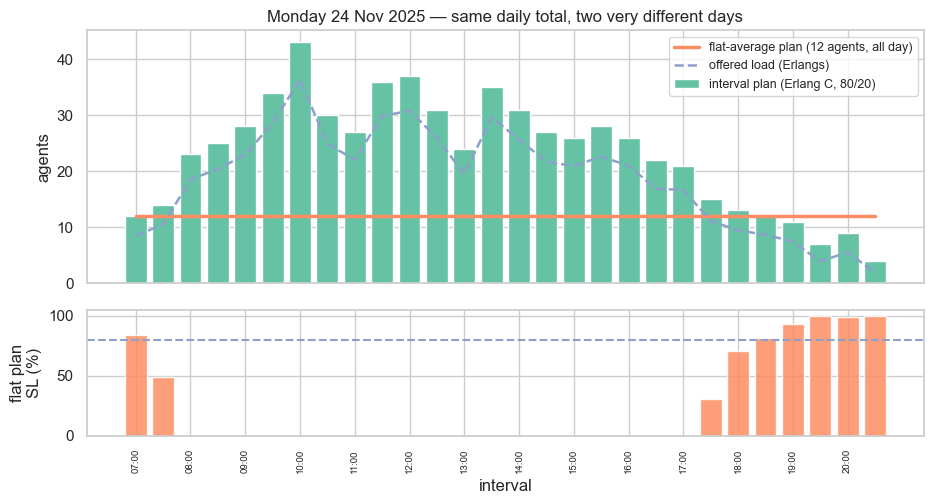

In [20]:
open_h = len(q) * 0.5
flat_raw = work_h / open_h
FLAT_N = math.ceil(flat_raw)
q["sl_flat"] = [service_level(FLAT_N, a, s) for a, s in zip(q.A, q.aht_s)]

flat_labour, flat_lost_eur, flat_lost_n = price_plan([FLAT_N] * len(q))
iv_labour, iv_lost_eur, iv_lost_n = price_plan(q.req.tolist())
unstable = q.A >= FLAT_N

print(f"flat-average plan: {flat_raw:.2f} -> {FLAT_N} agents in every interval "
      f"({FLAT_N * open_h / (1 - SHRINKAGE) / weeks_q / 40:.1f} FTE)")
print(f"  intervals below the 80 % SLA : {(q.sl_flat < SLA_TARGET).mean():.1%}")
print(f"  intervals over capacity      : {unstable.mean():.1%}, carrying "
      f"{q.contacts[unstable].sum() / q.contacts.sum():.1%} of the quarter's contacts")
print(f"  contact-weighted service level: {(q.sl_flat * q.contacts).sum() / q.contacts.sum():.1%}")
print()
print(f"{'':<22}{'labour':>13}{'abandonment':>14}{'total':>14}")
for name, lab, ab in [("flat-average plan", flat_labour, flat_lost_eur),
                      ("interval plan", iv_labour, iv_lost_eur)]:
    print(f"{name:<22}{lab:>13,.0f}{ab:>14,.0f}{lab + ab:>14,.0f}")
print(f"\nthe flat plan saves EUR {iv_labour - flat_labour:,.0f} of wages "
      f"and gives back EUR {flat_lost_eur - iv_lost_eur:,.0f} at the queue "
      f"-> EUR {(flat_labour + flat_lost_eur) - (iv_labour + iv_lost_eur):,.0f} worse per quarter")

# FIG 5 -- one Monday, two plans
day = q.loc["2025-11-24"]
xs = np.arange(len(day))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.5, 5.2), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})
ax1.bar(xs, day.req, color="#66c2a5", label="interval plan (Erlang C, 80/20)")
ax1.step(xs, [FLAT_N] * len(day), where="mid", color="#fc8d62", lw=2.5,
         label=f"flat-average plan ({FLAT_N} agents, all day)")
ax1.plot(xs, day.A, color="#8da0cb", lw=1.8, ls="--", label="offered load (Erlangs)")
ax1.set_ylabel("agents")
ax1.set_title("Monday 24 Nov 2025 — same daily total, two very different days")
ax1.legend(fontsize=9, loc="upper right")
ax2.bar(xs, day.sl_flat * 100, color="#fc8d62", alpha=0.85)
ax2.axhline(SLA_TARGET * 100, color="#8da0cb", ls="--", lw=1.5)
ax2.set_ylabel("flat plan\nSL (%)")
ax2.set_ylim(0, 105)
ax2.set_xticks(xs[::2])
ax2.set_xticklabels([t.strftime("%H:%M") for t in day.index[::2]], rotation=90, fontsize=7)
ax2.set_xlabel("interval")
plt.tight_layout()

print(f"this Monday: {day.contacts.sum():,} contacts; interval plan ranges "
      f"{day.req.min():.0f}-{day.req.max():.0f} agents; the flat plan sits at {FLAT_N} all day")
print(f"flat plan meets the SLA in {(day.sl_flat >= SLA_TARGET).sum()} of {len(day)} intervals")

The two-panel chart is the whole lesson, and the numbers under it are the invoice.

The flat plan is **42.0 FTE and €839,040** — genuinely **€216,111 cheaper in wages** than the interval plan's **52.8 FTE and €1,055,151**. That is why it survives budget reviews. But it misses the SLA in **52.4 %** of the quarter's intervals, is **over capacity outright in 42.4 %** of them — intervals carrying **70.0 % of all contacts** — and delivers a contact-weighted service level of **24.2 %** against an 80 % promise. Priced at §5.2's €15.24 per abandoned contact, that is **€1,433,108** of repeat handling, churn and goodwill against the interval plan's **€192,001**: the flat plan is **€1,024,996 worse per quarter**, having "saved" €216k.

Look at the lower panel. The flat plan is fine at 07:00, fine again after 18:30, and **flat zero from 08:00 to 17:00** — nine and a half consecutive hours. It never fails *slightly*. That is the signature of an averaged plan: it is not a bit wrong everywhere, it is completely wrong in the middle and wasteful at the edges, and the daily total conceals both perfectly.

> ⚠️ **The generalised failure mode.** Any plan built on an aggregate of a **convex** relationship is wrong in the same direction — and staffing, safety stock (NB 26), lead-time variance (A8 §3) and cash buffers (A6) are all convex. The rule to carry: **aggregate the euros, never the inputs.** Compute the decision at the resolution the decision is made, then sum.

## 6. The AI deflection question — what the vendor's slide leaves out

HelpDeskAI is, after all, an AI company. The new self-service bot fronts every incoming contact, and the pilot report is unambiguous: **30 % of contacts are contained** — resolved without a human. The vendor's slide says the rest:

> *"30 % deflection = 30 % fewer contacts = 30 % fewer agents. At €1.06 M of quarterly staffing cost, that is **€317,000 a quarter**. The platform costs €55,000. Payback: immediate."*

Every number on that slide is arithmetically correct and the conclusion is wrong, for three separate reasons that compound:

- **(a) Mix shift.** The bot resolves the **easy** contacts. Password resets are 3.4-minute contacts and the bot eats most of them; integration failures are 13.5-minute contacts and the bot eats none. The 70 % of contacts that remain are *not the average contact* — they are the hard tail, so the **residual AHT rises**. Cutting 30 % of contacts does not cut 30 % of workload.
- **(b) Interval profile.** Containment is not uniform across the grid. The easy self-service work clusters in the quiet intervals (§1 planted this), and during peaks — launches, incidents, Monday morning — customers skip the bot and demand a human. So the bot helps **least exactly where the roster is sized**.
- **(c) Escalations arrive harder.** A contact that fails the bot and reaches an agent is not a fresh contact: the customer has already explained the problem once, and a fraction of them are now annoyed. Handle time on escalations carries a penalty.

And underneath all three sits §4's staircase: **even a uniform 30 % volume cut is not a 30 % agent cut**, because the buffer does not scale with the work. Let's compute the whole thing.

In [21]:
CONTAINMENT = {"password & how-to": 0.74, "billing": 0.34,      # bot containment by type
               "technical": 0.10, "integration": 0.00}
PEAK_DROP = 0.30        # containment falls this much at the busiest intervals (people want a human)
ESC_REPEAT_MIN = 0.30   # "I already told the bot" -- extra minutes on every escalation
ANGRY_SHARE, ANGRY_MIN = 0.08, 3.0     # and a minority arrive properly annoyed
ESCALATION_MIN = ESC_REPEAT_MIN + ANGRY_SHARE * ANGRY_MIN

keep = 1 - PEAK_DROP * q.busyness                                # interval-level multiplier
residual = pd.DataFrame(
    {t: q[t] * (1 - np.clip(CONTAINMENT[t] * keep, 0, 0.95)) for t in TYPES}, index=q.index)
res_v = residual.sum(axis=1)
res_work = sum(residual[t] * AHT_MIN[t] for t in TYPES)
res_aht = res_work / res_v.clip(lower=1e-6) * 60 + ESCALATION_MIN * 60

CONTAIN_OVERALL = 1 - res_v.sum() / q.contacts.sum()
hi_q = q.contacts >= q.contacts.quantile(0.90)
lo_q = q.contacts <= q.contacts.quantile(0.25)
print(f"overall containment: {CONTAIN_OVERALL:.1%}   (the vendor's '30 %')")
print(f"  in the busiest 10 % of intervals : {1 - res_v[hi_q].sum() / q.contacts[hi_q].sum():.1%}")
print(f"  in the quietest 25 %             : {1 - res_v[lo_q].sum() / q.contacts[lo_q].sum():.1%}")
print(f"\nAHT before                  : {AHT_S / 60:.2f} min")
print(f"AHT after the mix shift     : {res_work.sum() / res_v.sum():.2f} min")
print(f"AHT after escalation penalty: {res_aht.mul(res_v).sum() / res_v.sum() / 60:.2f} min "
      f"(+{res_aht.mul(res_v).sum() / res_v.sum() / AHT_S - 1:.1%})")
print(f"\nworkload: {res_work.sum() / 60 + ESCALATION_MIN * res_v.sum() / 60:,.0f} h "
      f"vs {work_h:,.0f} h before "
      f"-> only {1 - (res_work.sum() + ESCALATION_MIN * res_v.sum()) / (work_h * 60):.1%} less work")


def fte_of(agents):
    return sum(agents) * 0.5 / (1 - SHRINKAGE) / weeks_q / 40


def cost_of(agents):
    return sum(agents) * 0.5 / (1 - SHRINKAGE) * AGENT_HOUR_EUR


# Step the vendor's claim down to the truth, one correction at a time.
pooled_aht = res_work.sum() / res_v.sum() * 60          # mix-shifted AHT, pooled over the quarter
steps = [("vendor slide: -30 % contacts = -30 % agents", FTE * (1 - CONTAIN_OVERALL))]
n_scale = [agents_required(offered_load(v * (1 - CONTAIN_OVERALL), s), s)
           for v, s in zip(q.contacts, q.aht_s)]
steps.append(("+ Erlang staircase (the buffer stays)", fte_of(n_scale)))
n_mix = [agents_required(offered_load(v * (1 - CONTAIN_OVERALL), pooled_aht), pooled_aht)
         for v in q.contacts]
steps.append(("+ (a) mix shift: residual AHT 6.90 -> 8.03 min", fte_of(n_mix)))
n_prof = [agents_required(offered_load(v, pooled_aht), pooled_aht) for v in res_v]
steps.append(("+ (b) containment varies by interval", fte_of(n_prof)))
n_hon = [agents_required(offered_load(v, s), s) for v, s in zip(res_v, res_aht)]
steps.append(("+ (c) escalations arrive harder", fte_of(n_hon)))

print(f"{'':<48}{'FTE':>7}{'vs today':>10}")
print(f"{'today (no bot)':<48}{FTE:>7.1f}{'':>10}")
for label, value in steps:
    print(f"{label:<48}{value:>7.1f}{value / FTE - 1:>+10.1%}")

honest_cost = cost_of(n_hon)
base_cost = paid_h * AGENT_HOUR_EUR
print(f"\nnaive saving  : EUR {base_cost * CONTAIN_OVERALL:,.0f} / quarter")
print(f"honest saving : EUR {base_cost - honest_cost:,.0f} / quarter "
      f"({1 - honest_cost / base_cost:.1%} of headcount)")
print(f"the gap       : EUR {base_cost * CONTAIN_OVERALL - (base_cost - honest_cost):,.0f} "
      f"of savings that were never there")

overall containment: 30.2%   (the vendor's '30 %')
  in the busiest 10 % of intervals : 24.4%


  in the quietest 25 %             : 39.9%

AHT before                  : 6.90 min
AHT after the mix shift     : 8.03 min
AHT after escalation penalty: 8.57 min (+24.2%)

workload: 12,514 h vs 14,494 h before -> only 13.7% less work
                                                    FTE  vs today
today (no bot)                                     52.8          
vendor slide: -30 % contacts = -30 % agents        36.8    -30.2%
+ Erlang staircase (the buffer stays)              39.3    -25.6%
+ (a) mix shift: residual AHT 6.90 -> 8.03 min     44.6    -15.6%
+ (b) containment varies by interval               44.4    -15.9%
+ (c) escalations arrive harder                    46.9    -11.2%

naive saving  : EUR 319,118 / quarter
honest saving : EUR 118,099 / quarter (11.2% of headcount)
the gap       : EUR 201,020 of savings that were never there


The waterfall is the deliverable. Read it as five sentences:

1. The vendor's slide says **36.8 FTE** (−30.2 %).
2. Apply nothing but §4's staircase — a *uniform* 30 % volume cut, same handle times — and it is already **39.3 FTE (−25.6 %)**. Removing contacts does not remove the variability buffer, and in the small intervals the buffer *is* the staffing.
3. **(a) Mix shift** is the big one: the residual AHT rises from **6.90 to 8.03 minutes** because the bot ate the 3.4-minute contacts, and the plan lands at **44.6 FTE (−15.6 %)**. Half the vendor's saving disappears here.
4. **(b) The interval profile** takes it to **44.4 FTE (−15.9 %)** — and this is the correction that looks like nothing and *is* the dangerous one. In aggregate it nearly cancels: the bot deflects only **24.4 %** in the busiest decile against **39.9 %** in the quietest quartile, but the peaks are also where the residual AHT rises least (they were already hard-contact-heavy). The cancellation is an accident of this data, and it hides where the saving moved to — see the chart below.
5. **(c) Escalations** carry **+0.54 minutes** each ("I already told the bot", plus 8 % who arrive annoyed), pushing the effective AHT to **8.57 minutes** and the plan to **46.9 FTE**.

**Net: −11.2 % of headcount, not −30 %.** In euros, **€118,099** per quarter instead of **€319,118** — a **€201,020 gap between the slide and the plan**, every quarter, on a business case somebody was about to sign.

          contacts deflected  agents saved  share of agent-hours
band                                                            
quietest               0.403         0.135                 0.064
quiet                  0.382         0.144                 0.112
mid                    0.344         0.133                 0.179
busy                   0.293         0.108                 0.275
busiest                0.257         0.091                 0.369


 containment  AHT after    FTE   saving EUR   net of bot


      12.1%      7.81m   52.6        4,614      -50,386
      18.1%      8.03m   50.7       42,967      -12,033
      24.2%      8.28m   48.8       80,424       25,424
      30.2%      8.57m   46.9      118,099       63,099
      36.3%      8.92m   44.9      157,374      102,374
      39.8%      9.11m   43.7      182,210      127,210

break-even containment: 20.1% of contacts (below this the bot costs more than it saves)
at the measured 30.2%: honest net EUR 63,099/quarter; the slide promised EUR 264,118


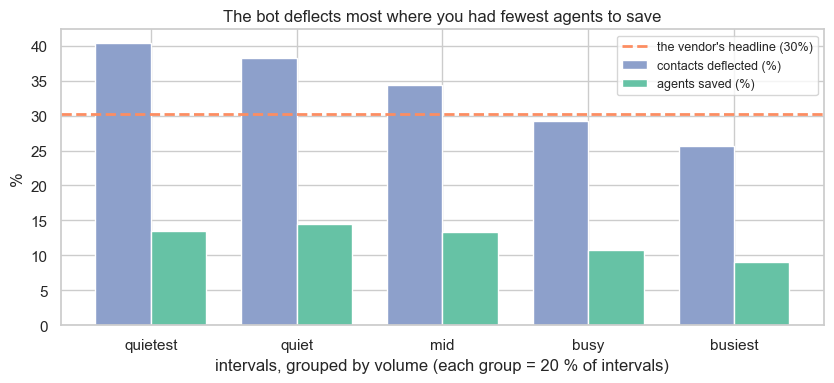

In [22]:
# FIG 6 -- where the saving actually is (and is not)
q["req_bot"] = n_hon
q["res_v"] = res_v
q["band"] = pd.qcut(q.contacts.rank(method="first"), 5,
                    labels=["quietest", "quiet", "mid", "busy", "busiest"])
g = q.groupby("band", observed=True)[["contacts", "res_v", "req", "req_bot"]].sum()
by_band = pd.DataFrame({
    "contacts deflected": 1 - g.res_v / g.contacts,
    "agents saved": 1 - g.req_bot / g.req,
    "share of agent-hours": g.req / q.req.sum(),
})
print(by_band.round(3).to_string())

fig, ax = plt.subplots(figsize=(8.5, 4))
w = 0.38
xs = np.arange(len(by_band))
ax.bar(xs - w / 2, by_band["contacts deflected"] * 100, w, color="#8da0cb",
       label="contacts deflected (%)")
ax.bar(xs + w / 2, by_band["agents saved"] * 100, w, color="#66c2a5", label="agents saved (%)")
ax.axhline(CONTAIN_OVERALL * 100, color="#fc8d62", ls="--", lw=2,
           label=f"the vendor's headline ({CONTAIN_OVERALL:.0%})")
ax.set_xticks(xs)
ax.set_xticklabels(by_band.index)
ax.set_xlabel("intervals, grouped by volume (each group = 20 % of intervals)")
ax.set_ylabel("%")
ax.set_title("The bot deflects most where you had fewest agents to save")
ax.legend(fontsize=9)
plt.tight_layout()

BOT_QUARTER_EUR = 55_000.0     # platform licence + content maintenance (~0.5 FTE)

print(f"{'containment':>12}{'AHT after':>11}{'FTE':>7}{'saving EUR':>13}{'net of bot':>13}")
sens = []
for scale in [0.4, 0.6, 0.8, 1.0, 1.2, 1.4]:
    c_s = {t: min(CONTAINMENT[t] * scale, 0.95) for t in TYPES}
    r_s = pd.DataFrame({t: q[t] * (1 - np.clip(c_s[t] * keep, 0, 0.95)) for t in TYPES},
                       index=q.index)
    v_s = r_s.sum(axis=1)
    w_s = sum(r_s[t] * AHT_MIN[t] for t in TYPES)
    a_s = w_s / v_s.clip(lower=1e-6) * 60 + ESCALATION_MIN * 60
    n_s = [agents_required(offered_load(v, s), s) for v, s in zip(v_s, a_s)]
    saving = base_cost - cost_of(n_s)
    sens.append((1 - v_s.sum() / q.contacts.sum(), saving))
    print(f"{1 - v_s.sum() / q.contacts.sum():>11.1%}{a_s.mul(v_s).sum() / v_s.sum() / 60:>10.2f}m"
          f"{fte_of(n_s):>7.1f}{saving:>13,.0f}{saving - BOT_QUARTER_EUR:>13,.0f}")

sens = np.array(sens)
break_even = np.interp(BOT_QUARTER_EUR, sens[:, 1], sens[:, 0])
print(f"\nbreak-even containment: {break_even:.1%} of contacts "
      f"(below this the bot costs more than it saves)")
print(f"at the measured {CONTAIN_OVERALL:.1%}: honest net "
      f"EUR {base_cost - honest_cost - BOT_QUARTER_EUR:,.0f}/quarter; "
      f"the slide promised EUR {base_cost * CONTAIN_OVERALL - BOT_QUARTER_EUR:,.0f}")

Two readings, and then the memo.

**Where the saving went.** The band chart is correction (b) made visible. In the **busiest** quintile of intervals the bot deflects **25.7 %** of contacts and saves **9.1 %** of agents; in the **quietest** quintile it deflects **40.3 %** and saves **13.5 %**. The busiest quintile carries **36.9 %** of all agent-hours; the quietest carries **6.4 %**. So the deflection is concentrated in the intervals where each removed contact frees the least staffing — and, worse, the intervals where you can least easily *bank* the saving, because a roster is built from shifts, not half-hours. You cannot send a third of the floor home for the 10:00 peak and recall them at 20:00. The realisable saving is closer to what the **peak** intervals give up than to the quarterly average, which is another reason to treat −11.2 % as an upper bound rather than a promise.

**Is the bot worth it at all?** Yes — but the case is ordinary rather than transformational. At €55,000 a quarter the bot breaks even at **20.1 % containment** and currently returns **€63,099 a quarter net**, against the slide's **€264,118**. A 4.2× overstatement, produced with no dishonesty whatsoever: every input on the vendor's slide was measured correctly, and the error was entirely in the arithmetic connecting them.

> 🎯 **The honest business case, in the three lines a CFO will read.** *"Containment is real at 30 %, and it removes 13.7 % of the workload rather than 30 %, because the bot resolves the short contacts. After the queueing buffer and escalation load, the plan falls from 52.8 to 46.9 FTE — €118k a quarter against a €55k platform cost, so **€63k net**. The €317k figure in the proposal assumes agents scale linearly with contacts and that deflected contacts were average-length. Neither holds. We recommend proceeding, at the smaller number, and re-measuring containment by interval after one quarter."*

That paragraph is the entire value of this notebook, and it is also the Module 8 bridge: everything from NB 27 onwards is about building the bot in that sentence. Build it knowing what it is worth — and knowing that "what it deflects" and "what it saves" are two different measurements.

## 7. What real workforce-management teams add (honest section)

Everything above is the load-bearing 80 % — enough to size a centre, price an SLA and audit a business case. What a real WFM function layers on top, and where this notebook's model would mislead you:

- **Erlang C's three assumptions all leak.** *Nobody abandons:* false, and it matters most exactly where the model is worst — in overloaded intervals, where real abandonment relieves the queue and Erlang C reports infinity. **Erlang A** adds a patience distribution and is what serious planners use (Stretch A builds it). *Exponential handle times:* our own generator used a lognormal, which has a longer tail and therefore slightly worse queues than Erlang C admits. *Poisson arrivals:* incidents and launches make arrivals **over-dispersed** — clustered, correlated within an interval — and clustering hurts more than the model says. The professional habit is to use Erlang C to *plan* and simulation to *verify* the intervals that matter.
- **Skill-based routing, where the formula simply stops.** Real floors have agents with overlapping skills — German+English, billing+technical, tier 1+tier 2 — and Erlang C has no closed form for that. Two agents who each cover two of three queues do not behave like any single-queue formula. The answer is **simulation** (Stretch B), and the design lesson is worth more than either: **pooling is enormously valuable** (one queue of 34 beats two of 17 by far more than intuition suggests, see §4's buffer numbers) while **over-pooling destroys expertise**. That trade-off is a business decision informed by a simulator, not a formula.
- **Shift scheduling is an integer program.** §5 produced a *requirement curve* — agents needed per interval. Turning that into shifts (fixed lengths, breaks, contracts, weekend fairness, part-timers, minimum rest, works-council agreements) is a classic **set-covering problem**: minimise paid hours subject to covering every interval's requirement. `scipy.optimize.linprog` plus rounding gets you a usable answer for a small centre; commercial WFM tools solve the same problem with a mixed-integer solver and a decade of accumulated constraints. The gap between the requirement curve and the achievable roster is typically **5–15 %** — real money that §5 quietly ignored (Stretch D).
- **Adherence and the forecast-versus-actual review.** A plan is a hypothesis. Mature teams run a weekly cycle: forecast vs actual **volume**, forecast vs actual **AHT** (this one drifts constantly and is usually the culprit), plan vs actual **adherence** (were the rostered people actually logged in when the plan said?), and shrinkage vs assumption. Most SLA misses trace to one of those four, not to the queueing model.
- **Outsourcing, offshoring and the flex layer.** A BPO partner sells you exactly what §4 says is expensive: **variability absorption**. The economics are that they pool your peak with other clients' troughs, so the honest comparison is not €/hour against €38 but the *marginal* cost of your peak intervals against theirs — plus quality, security, GDPR and the AHT penalty of a less-trained agent.
- **Callbacks, deferrable work and the queues that aren't queues.** E-mail and back-office work have hours of allowed latency; they are the ideal filler for the trough intervals and change the shape of everything above. A "virtual queue" (keep your place, we'll call you back) converts wait time into a scheduling problem and is often the cheapest SLA improvement available.
- **What this notebook did not solve at all:** multi-channel concurrency (a chat agent handles two or three sessions at once — which changes the queueing model outright), intraday re-forecasting and real-time management (the 10:00 decision to pull people off e-mail), agent-level performance and its effect on AHT, and the fairness and works-council dimensions of any schedule (A5's territory, and legally binding in Germany).

## 🧠 The story so far — one screen

| # | The move | The number that carries it |
|---|---|---|
| 1 | Two years of 30-minute intervals; the "average day" audited | mean interval 45.9 contacts — only **14.9 %** of intervals land within ±20 % of it |
| 2 | Calendar-feature forecast beats seasonal-naive at interval level | MAE **5.87** vs **7.73** (−24.1 %); weekly totals within ±2.6 % |
| 2 | The error that becomes a buffer | p90 of actual/forecast = **1.221** → one interval in ten arrives +22 % |
| 3 | Erlang C written from scratch, checked against a simulation | P(wait) **0.209** vs **0.199**; SL **83.6 %** vs **84.7 %** |
| 3 | Offered load ≠ agents | 20.0 Erlangs needs **25** agents for 80/20 |
| 4 | The staircase, both directions | +5 % volume → **+14.3 %** agents in the 20:00 interval; −30 % volume → only **−26.2 %** agents |
| 4 | The occupancy cliff | 80 % → SL 83.6 %, ASA 17 s · **95 % → SL 27.5 %, ASA 315 s** |
| 5 | Shrinkage: productive hours ≠ paid hours | 37.0 → **52.8 FTE**, **+€316,545**/quarter from one division |
| 5 | The cost-optimal service level is a U | optimum **88 %**; the contracted 80 % costs **€22,056** more, 98 % costs €103,100 more |
| 5 | The flat-average baseline, dissected | 42.0 FTE, €216k cheaper in wages — misses the SLA in **52.4 %** of intervals, **€1,024,996 worse** overall |
| 6 | The deflection waterfall | −30.2 % → −25.6 % (staircase) → −15.6 % (mix) → −15.9 % (profile) → **−11.2 %** (escalations) |
| 6 | The honest business case | **€118,099** saved vs the slide's **€319,118** — a **€201,020** gap; net of the bot, **€63k** vs €264k |

## 🧪 Practice exercises

Try each one **before** opening the solution. Starters run as-is.

### Exercise 1 — ⭐ The rule of three, audited

For the Q4 Monday profile in `curve`, compute for each interval the ratio `agents / A` — how many agents the SLA demands per Erlang of work. Print the five most expensive and five cheapest intervals, and answer: if HelpDeskAI could move **one contact** from its most expensive interval to its cheapest, how much staffing does that free? (Then say why that is exactly what a callback offer does.)

In [23]:
# Starter
# curve["per_erlang"] = curve.agents / curve.A
# then .nlargest / .nsmallest on it

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
c2 = curve.copy()
c2["per_erlang"] = c2.agents / c2.A
c2["contacts_per_agent"] = c2.contacts / c2.agents
print(c2.nlargest(5, "per_erlang")[["hour", "contacts", "A", "agents", "per_erlang",
                                    "contacts_per_agent"]].round(2).to_string(index=False))
print(c2.nsmallest(5, "per_erlang")[["hour", "contacts", "A", "agents", "per_erlang",
                                     "contacts_per_agent"]].round(2).to_string(index=False))
worst, best = c2.loc[c2.per_erlang.idxmax()], c2.loc[c2.per_erlang.idxmin()]
print(f"\nan agent handles {best.contacts_per_agent:.1f} contacts in the {best.hour:.1f}h interval "
      f"but only {worst.contacts_per_agent:.1f} in the {worst.hour:.1f}h one")
```

The 20:30 interval needs **2.04 agents per Erlang**; 11:30 needs **1.19**. In the currency a manager feels, an agent in the busy interval gets through **3.4 contacts** in the half-hour while an agent in the quiet one gets through **2.3** — a **49 %** productivity difference produced by *nothing but queue size*. Never appraise agents on contacts-per-hour without adjusting for the interval they were rostered into.

And the callback connection: offering "we'll ring you back at 11:30" moves a contact from a 2.04-agents-per-Erlang interval into a 1.19 one. It is the cheapest capacity a contact centre can buy — no hiring, no vendor, just the observation that customer *patience* is a resource and the requirement curve is not flat.
</details>

### Exercise 2 — ⭐⭐ How much SLA does one more agent buy?

Take the Q4 Monday 10:00 interval (**A ≈ 27.9 Erlangs**). Sweep the agent count from `int(A)+1` to `int(A)+15` and build a small table of service level, ASA, occupancy and the **marginal** service-level gain per added agent. At what agent count does the marginal agent stop being worth €19 (half an hour at €38/h), given §5.2's €15.24 per abandoned contact and the 112 contacts in that interval?

In [24]:
# Starter
# a10 = curve.loc[curve.hour == 10.0].iloc[0]
# for n in range(int(a10.A) + 1, int(a10.A) + 16): ... service_level / asa / p_abandon

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
a10 = curve.loc[curve.hour == 10.0].iloc[0]
rows = []
for n in range(int(a10.A) + 1, int(a10.A) + 16):
    ab = p_abandon(n, a10.A, AHT_S)
    rows.append({"n": n, "occ": a10.A / n, "SL": service_level(n, a10.A, AHT_S),
                 "ASA": asa(n, a10.A, AHT_S), "lost EUR": a10.contacts * ab * ABANDON_EUR})
t = pd.DataFrame(rows).set_index("n")
t["marginal SL"] = t.SL.diff()
t["marginal EUR saved"] = -t["lost EUR"].diff()
print(t.round(3).to_string())
worth = t[t["marginal EUR saved"] > 0.5 * AGENT_HOUR_EUR]
print(f"\nthe marginal agent still pays for itself up to n = {worth.index.max()} "
      f"(SL {t.loc[worth.index.max(), 'SL']:.1%})")
```

The marginal service-level gain runs **+24.0 pp, +18.9, +14.6, +11.2, +8.4** … and the marginal euro saved falls with it, from **€574** for the first extra agent to **€2.40** for the fifteenth. The last agent worth its €19 lands at **n = 37**, a service level of **95.5 %**.

That is *well above* §5.2's quarter-wide optimum of 88 %, and the discrepancy is the lesson rather than a bug. §5.2 searched over plans with **one target for every interval**; this interval is large, so each extra agent removes a great deal of waiting and keeps paying for itself far longer than it would in a five-agent interval. Run the marginal test in *every* interval instead of imposing a common target and the quarter comes out at **55.5 FTE and €1,216,081** — about **€9,000 cheaper** than the best uniform-target plan, with a contact-weighted service level of **90.9 %** made of high service in the big intervals and lower service in the small ones. The decision rule is one line and it never mentions a target: **hire the marginal agent while `Δ(abandoned contacts) × €15.24 > €19`.**
</details>

### Exercise 3 — ⭐⭐ Debug me 🐞: the plan that hits its SLA on paper

A colleague builds next quarter's plan from **each day's average load** — a genuine improvement on the flat plan, since it adapts to day of week and seasonality — and sizes it with the very Erlang C function you wrote. Their report: *"Every day of the quarter is planned to at least an 80 % service level. The plan meets the SLA."*

Their code runs, uses the right formula, and the claim is false. Reproduce it, find the flaw, and quantify what it costs.

In [25]:
# their analysis -- it runs fine and uses the right formula; that's the point
day_totals = q.groupby(q.index.normalize()).agg(vol=("contacts", "sum"), aht=("aht_s", "mean"))
day_totals["A"] = day_totals.vol / 14 * day_totals.aht / 3600      # 14 opening hours
day_totals["agents"] = [agents_required(a, s) for a, s in zip(day_totals.A, day_totals.aht)]
day_totals["SL on paper"] = [service_level(n, a, s) for n, a, s
                             in zip(day_totals.agents, day_totals.A, day_totals.aht)]
print(day_totals.head().round(3).to_string())
print(f"\nworst day's planned service level: {day_totals['SL on paper'].min():.1%} "
      f"-> 'every day meets the 80 % SLA'")
print(f"total: {day_totals.agents.sum() * 14 / (1 - SHRINKAGE) / weeks_q / 40:.1f} FTE")

             vol      aht       A  agents  SL on paper
2025-10-01  1414  398.821  11.189      15        0.826
2025-10-02  1430  399.680  11.340      15        0.809
2025-10-03  1248  393.992   9.756      14        0.879
2025-10-04   574  392.614   4.471       7        0.814
2025-10-05   408  371.314   3.006       6        0.915

worst day's planned service level: 80.1% -> 'every day meets the 80 % SLA'
total: 52.6 FTE


<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
q["n_daily"] = q.index.normalize().map(day_totals.agents).astype(int)
q["sl_daily"] = [service_level(n, a, s) for n, a, s in zip(q.n_daily, q.A, q.aht_s)]
print(f"on paper : every day >= {day_totals['SL on paper'].min():.0%}")
print(f"reality  : {(q.sl_daily < SLA_TARGET).mean():.1%} of intervals miss the SLA")
print(f"           contact-weighted service level {(q.sl_daily * q.contacts).sum() / q.contacts.sum():.1%}")
lab_d, ab_d, _ = price_plan(q.n_daily.tolist())
lab_i, ab_i, _ = price_plan(q.req.tolist())
print(f"\ndaily-average plan: {q.n_daily.sum() * 0.5 / (1 - SHRINKAGE) / weeks_q / 40:.1f} FTE, "
      f"labour EUR {lab_d:,.0f} + abandonment EUR {ab_d:,.0f} = EUR {lab_d + ab_d:,.0f}")
print(f"interval plan     : {FTE:.1f} FTE, labour EUR {lab_i:,.0f} + abandonment "
      f"EUR {ab_i:,.0f} = EUR {lab_i + ab_i:,.0f}")
print(f"cost of averaging within the day: EUR {(lab_d + ab_d) - (lab_i + ab_i):,.0f} per quarter")
```

The bug is not in the formula — it is in **what the formula was fed**. Erlang C is being applied to a *day-average* offered load, and the service level it reports is the service level of a fictional day on which volume arrives evenly from 07:00 to 21:00. It does not. The plan's on-paper minimum is **80.1 %**; in reality **50.5 %** of the quarter's intervals miss the SLA and the contact-weighted service level is **37.9 %**.

The tell is diagnostic and general: the plan buys almost exactly the same number of FTE as the correct one (**52.6** vs **52.8**) while delivering half the service. **It is not under-resourced, it is mis-distributed** — too many agents in the morning ramp and the evening tail, far too few from 09:30 to 16:00. Averaging inside the planning unit is the failure mode; the fix is one line — size *each interval* from *its own* load — and it costs nothing.

Priced out, averaging inside the day costs **€945,286** a quarter — almost the entire labour bill again, paid in repeat contacts and churn.

> This is A8's "averages lie" lesson in its operational form, and it is the reason WFM systems are built around interval grids rather than daily targets. Any time you see a plan whose service level is computed at a coarser resolution than the plan is executed, the number is decorative.
</details>

### Exercise 4 — ⭐⭐ What if handle time drifts?

AHT is the least stable input in any staffing plan — a UI change, a new product, a policy about verification, and it moves 5 % without anybody filing a ticket. Re-cost the quarter's interval plan for AHT drifts of **−10 %, −5 %, 0, +5 %, +10 %**, reporting FTE and quarterly labour cost. Then answer the planning question: is a 5 % AHT error more or less expensive than a 5 % volume error, and why?

In [26]:
# Starter
# for drift in (-0.10, -0.05, 0.0, 0.05, 0.10):
#     ns = [agents_required(offered_load(v, s * (1 + drift)), s * (1 + drift)) for v, s in ...]

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
rows = []
for drift in (-0.10, -0.05, 0.0, 0.05, 0.10):
    ns_a = [agents_required(offered_load(v, s * (1 + drift)), s * (1 + drift))
            for v, s in zip(q.contacts, q.aht_s)]
    ns_v = [agents_required(offered_load(v * (1 + drift), s), s)
            for v, s in zip(q.contacts, q.aht_s)]
    rows.append({"drift": drift,
                 "FTE (AHT drift)": fte_of(ns_a), "EUR (AHT drift)": cost_of(ns_a),
                 "FTE (volume drift)": fte_of(ns_v), "EUR (volume drift)": cost_of(ns_v)})
d = pd.DataFrame(rows).set_index("drift")
print(d.round(1).to_string())
print(f"\n+5 % AHT costs EUR {d.loc[0.05, 'EUR (AHT drift)'] - d.loc[0.0, 'EUR (AHT drift)']:,.0f}; "
      f"+5 % volume costs EUR {d.loc[0.05, 'EUR (volume drift)'] - d.loc[0.0, 'EUR (volume drift)']:,.0f}")
```

They are nearly **identical** — and that is the answer worth having. Offered load is $A = \lambda \times \text{AHT}$, a **product**, so a 5 % error in either factor is a 5 % error in $A$, and the plan does not care which factor moved. (The tiny difference is integer rounding landing differently across intervals.)

The operational consequence is the point: forecasting teams pour effort into volume and treat AHT as a constant taken from last year's report. **AHT deserves exactly as much forecasting discipline as volume** — it has its own weekly seasonality (Mondays are messier), its own trend (products get more complex), and its own step changes (a new release, a new script, a bot that removes all the short contacts — §6 is precisely an AHT-forecasting problem wearing a deflection costume).
</details>

## 🧠 Stretch exercises

### Stretch exercise A — ⭐⭐⭐ Erlang A: what happens when customers hang up

§5.2 bolted an approximate abandonment probability onto Erlang C. Build the real thing by **simulation**: extend `simulate_queue` so each arrival draws a patience from an exponential distribution (mean 90 s) and abandons if it would wait longer than that. Run it for A = 20 Erlangs at n = 21, 23, 25 and 27 and compare three things against the Erlang C prediction: service level, ASA **among answered contacts**, and abandonment rate. Then the interesting case: run it at **n = 19** (below the offered load) and explain why the simulation gives a finite answer where Erlang C gives infinity — and what that means for §5.3's €1.4 M abandonment estimate.

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def simulate_erlang_a(n, a, aht_s, theta=90.0, n_arrivals=60_000, seed=1, warmup=2_000):
    rng = np.random.default_rng(seed)
    arrive = np.cumsum(rng.exponential(aht_s / a, n_arrivals))
    service = rng.exponential(aht_s, n_arrivals)
    patience = rng.exponential(theta, n_arrivals)
    free = np.zeros(n)
    wait = np.full(n_arrivals, np.nan)          # NaN = abandoned
    for i in range(n_arrivals):
        j = int(np.argmin(free))
        w = max(0.0, free[j] - arrive[i])
        if w > patience[i]:
            continue                            # hung up: never occupies an agent
        wait[i] = w
        free[j] = arrive[i] + w + service[i]
    w_ = wait[warmup:]
    ans = w_[~np.isnan(w_)]
    return {"abandoned": float(np.isnan(w_).mean()), "SL 20s": float((ans <= 20).mean()),
            "ASA answered": float(ans.mean())}

for n in (19, 21, 23, 25, 27):
    sim = simulate_erlang_a(n, 20.0, AHT_S)
    ec = service_level(n, 20.0, AHT_S)
    print(f"n={n}: sim SL {sim['SL 20s']:.3f} abandoned {sim['abandoned']:.3f} "
          f"ASA(answered) {sim['ASA answered']:6.1f}s   | Erlang C SL {ec:.3f}")
```

Two lessons, and the first one is bigger than it looks. **Erlang C is systematically pessimistic once patience is finite**, and not by a rounding error: at n = 23 the formula predicts **64.0 %** service level while the simulation delivers **92.1 %** (with **6.0 %** abandoned); at n = 25 it is **83.6 %** against **95.5 %**. The mechanism is simple — every customer who hangs up returns capacity to the queue, so the survivors are served faster than a model with infinite patience allows. Planning with Erlang C therefore buys a real safety margin, which is one reason it survives as the industry standard despite an assumption everybody knows is false. It also means the *right* comparison for an SLA is Erlang A, and that the answered-contact service level and the all-contact service level are different numbers — worth pinning down before signing a contract that names one of them.

**Where the queue is overloaded** (n = 19 < A = 20) the difference is qualitative, not quantitative. Erlang C says the wait is infinite and the service level is zero; the simulation reports **80.5 %** answered within 20 s with **15.3 %** abandoned, because **abandonment is what stabilises an overloaded queue** — the callers who walk away are exactly what keeps it from growing. This is the caveat on §5.3's €1,433,108: the flat plan's damage is real and enormous, but the arithmetic that produced it lives outside Erlang C's domain of validity. In a memo, quote it as *"the busy intervals are over capacity; on the order of a million euros of repeat contacts and churn"* — not to the euro.
</details>

### Stretch exercise B — ⭐⭐⭐ Two skills, one floor: where the formula has no answer

HelpDeskAI wants to split its floor into **billing** and **technical** queues, with a small group of cross-trained agents who take whichever queue is longer. Erlang C has no formula for this. Simulate it: two Poisson arrival streams (use the Q4 10:00 interval's volumes, split by type), agents of three kinds (billing-only, technical-only, both), and a routing rule (a free universal agent serves the longest-waiting contact). Compare three designs at equal total headcount — fully specialised, fully pooled, and 20 % universal — on each queue's service level.

Then answer the design question: how many universal agents does it take to recover most of the pooling benefit, and what does that suggest about training budgets?

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
def sim_two_skill(n_b, n_t, n_u, a_b, a_t, aht_s, n_arr=40_000, seed=3, warmup=2_000):
    rng = np.random.default_rng(seed)
    # merge two streams into one event list
    arr_b = np.cumsum(rng.exponential(aht_s / a_b, n_arr))
    arr_t = np.cumsum(rng.exponential(aht_s / a_t, n_arr))
    kind = np.concatenate([np.zeros(n_arr, int), np.ones(n_arr, int)])
    arr = np.concatenate([arr_b, arr_t])
    order = np.argsort(arr)
    arr, kind = arr[order], kind[order]
    svc = rng.exponential(aht_s, len(arr))
    free = [np.zeros(n_b), np.zeros(n_t), np.zeros(n_u)]     # billing / technical / universal
    wait = np.empty(len(arr))
    for i, (t0, k) in enumerate(zip(arr, kind)):
        pools = [k, 2] if free[2].size else [k]
        best_pool, best_j, best_free = None, None, np.inf
        for p in pools:
            if free[p].size == 0:
                continue
            j = int(np.argmin(free[p]))
            if free[p][j] < best_free:
                best_pool, best_j, best_free = p, j, free[p][j]
        start = max(t0, best_free)
        wait[i] = start - t0
        free[best_pool][best_j] = start + svc[i]
    w = wait[warmup:]
    kk = kind[warmup:]
    return {"billing SL": float((w[kk == 0] <= 20).mean()),
            "technical SL": float((w[kk == 1] <= 20).mean()),
            "overall SL": float((w <= 20).mean())}

A_B, A_T, TOTAL = 9.0, 19.0, 34
for name, (nb_, nt_, nu_) in {
        "specialised (12/22/0)": (12, 22, 0),
        "20 % universal (9/18/7)": (9, 18, 7),
        "fully pooled (0/0/34)": (0, 0, TOTAL)}.items():
    print(f"{name:24s}", {k: round(v, 3) for k, v in
                          sim_two_skill(nb_, nt_, nu_, A_B, A_T, AHT_S).items()})
```

The pattern is the one every WFM team eventually rediscovers: **the first few universal agents buy most of the benefit**. At 34 agents in total, full specialisation delivers an overall service level of **69.5 %** (billing 77.2 %, technical 61.7 %); adding a seven-person universal pool lifts it to **83.1 %**; full pooling reaches **88.0 %**. Seven cross-trained people recover roughly **three quarters** of the pooling gain. Full specialisation runs two small queues, each paying §4's small-team premium, and one of them is usually starving while the other drowns. Full pooling is the best queueing outcome — but it requires everyone trained on everything, which is expensive, slow, and degrades quality on the deep-technical work. Around 20 % cross-trained typically recovers the large majority of the pooling benefit, which is why "train a flex layer" beats both "train nobody" and "train everybody" as a budget line. And note what got you here: no formula existed, so you simulated. That is the correct reflex.
</details>

### Stretch exercise C — ⭐⭐⭐ Buying a quantile, not a point forecast

§2 measured the forecast's p90 ratio at **1.221** and §5 then planned on perfect foresight. Close the loop: refit the §2 model, produce a forecast for the last eight weeks, and build **three** plans — on the point forecast, on the p80 forecast, and on the p90 forecast. Score each against the *actual* volumes: realised service level, realised abandonment, labour cost, total cost. Which quantile minimises total cost — and how does that number relate to §5.2's optimal service level?

*(Hint: this is NB 26's newsvendor with agents instead of stock, and the critical ratio is the same object. Under-staffing costs abandonment; over-staffing costs an idle agent-hour.)*

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
te = test.copy()
te["pred"] = pred
te = te.join(iv[["aht_s"]])
te["A"] = offered_load(te.contacts, te.aht_s)
rows = []
for label, mult in [("point forecast", 1.0), ("p80", float(np.quantile(ratio, 0.80))),
                    ("p90", BUFFER), ("perfect foresight", None)]:
    if mult is None:
        ns = [agents_required(offered_load(v, s), s) for v, s in zip(te.contacts, te.aht_s)]
    else:
        ns = [agents_required(offered_load(max(p, 0) * mult, s), s)
              for p, s in zip(te.pred, te.aht_s)]
    labour = sum(ns) * 0.5 / (1 - SHRINKAGE) * AGENT_HOUR_EUR
    lost = sum(v * p_abandon(n, a, s) for n, a, s, v in zip(ns, te.A, te.aht_s, te.contacts))
    sl = sum(service_level(n, a, s) * v for n, a, s, v
             in zip(ns, te.A, te.aht_s, te.contacts)) / te.contacts.sum()
    rows.append({"plan": label, "FTE-hours": sum(ns) * 0.5, "realised SL": sl,
                 "abandoned": lost, "labour EUR": labour,
                 "total EUR": labour + lost * ABANDON_EUR})
print(pd.DataFrame(rows).round(2).to_string(index=False))
```

Planning on the **point forecast** delivers a realised service level of **73 %** against an 80 % promise — because half the intervals arrive above the forecast and the SLA response to under-staffing is convex (§4.2's cliff), so the good intervals cannot compensate for the bad ones. Buying a **higher quantile** costs labour linearly and buys service level in the steep part of the curve: the p80 plan reaches **90 %** realised service at a total cost of **€821,077**, against **€908,976** for the point forecast — **€87,899 cheaper for eight weeks**, while spending €81,564 *more* on wages. The p90 plan is marginally worse again (**€827,185**), so the minimum sits around p80.

The structural insight is the one NB 26 taught with pallets: **you are never buying the forecast, you are buying a quantile of it**, and the right quantile is a **critical ratio** set by the cost of the two mistakes — here `cost of an idle agent-hour` against `cost of the abandonment an extra agent prevents`. Two notebooks, two industries, one formula.
</details>

### Stretch exercise D — ⭐⭐⭐ From requirement curve to roster: the set-covering problem

§5 produced agents needed *per interval*; a roster is built from **shifts**. Take one Monday's requirement, define candidate shifts (start every 30 minutes from 07:00, lengths of 4 and 8 hours, an unpaid half-hour break in the middle of the 8-hour ones), and solve `minimise Σ paid_hours(s) · x_s subject to Σ_{s covers i} x_s ≥ required_i` with `scipy.optimize.linprog` — then round the LP solution up to integers and repair any interval left short. Report the paid hours of the roster against the sum of the requirement curve, i.e. **the cost of the fact that people work in shifts rather than half-hours**.

<details>
<summary>💡 <b>Solution — click to expand</b></summary>

```python
from scipy.optimize import linprog

req = q.loc["2025-11-24"].req.to_numpy()
n_iv = len(req)
shifts, hours = [], []
for length in (8, 16):                       # 4h and 8h, measured in half-hour intervals
    for start in range(0, n_iv - length + 1):
        cover = np.zeros(n_iv)
        cover[start:start + length] = 1
        if length == 16:
            cover[start + 7] = 0             # unpaid break, mid-shift
        shifts.append(cover)
        hours.append(cover.sum() * 0.5)
A_ub = -np.array(shifts).T                   # -cover x <= -req
res = linprog(c=hours, A_ub=A_ub, b_ub=-req, bounds=(0, None), method="highs")
x = np.ceil(res.x - 1e-9)
covered = (np.array(shifts).T @ x)
print(f"LP lower bound   : {res.fun:,.1f} paid hours")
print(f"integer roster   : {float(x @ hours):,.1f} paid hours, "
      f"{int(x.sum())} shifts, short in {int((covered < req).sum())} intervals")
print(f"requirement curve: {req.sum() * 0.5:,.1f} agent-hours")
print(f"cost of shifts   : +{float(x @ hours) / (req.sum() * 0.5) - 1:.1%}")
```

The roster always costs **more** than the requirement curve, because a shift is a rectangle and the requirement is a mountain: the only way to cover the 10:00 peak is with people who are also present at 08:00 and 13:00, where they are not needed. That excess — here **+10.8 %**: a 56-shift roster of **360.5 paid hours** against a requirement curve of **325.5** — is the real reason part-time and split shifts exist, and it is a cost §5 quietly omitted from every euro in this notebook.

Two extensions worth the extra half hour: add a constraint that no more than 40 % of shifts may be part-time (watch the cost rise), and re-solve using the **deflected** requirement curve from §6 — the honest deflection saving shrinks *again*, because the bot flattens the trough more than the peak and rectangles are exactly the wrong shape for that.
</details>

## 🎁 Bonus mini-project — the staffing plan one-pager for the CFO

Write the single page that goes into next quarter's budget review. It has to survive a CFO who is good at arithmetic and hostile to consultants, so every number carries one of three tags: **measured** (computed from the interval history), **modelled** (Erlang C or the forecast, with its assumption named), or **assumed** (somebody chose it, and it is negotiable).

1. **The ask.** Headcount and euros for Q4: **52.8 FTE, €1,055,151** at the contracted 80/20 — against the **42.0 FTE** the flat plan implies. Explain the €216k *increase* in wages in one sentence a CFO will accept, and then show the €1.02 M it prevents. *(modelled; state the Erlang C assumptions)*
2. **The service level we are buying.** The U-curve, the **88 %** optimum, the €22,056 the contracted 80 % costs — and the recommendation, which is not necessarily to change the SLA. Say explicitly which curve the customer is paying for. *(modelled + assumed: the €15.24 abandonment cost is three assumptions in a trenchcoat; list them)*
3. **The three numbers that would change the answer.** Shrinkage (**30 % assumed — measure it**, ±5 points is ±5 FTE), AHT drift (±5 % is worth as much as ±5 % of volume, Exercise 4), and forecast quantile (the p90 buffer is +22.1 % on the intervals that matter). Give each a sensitivity, not an opinion.
4. **The bot.** The honest case: **€118k saved, €55k cost, €63k net**, against the proposal's €317k — with the three corrections named in one line each, and the re-measurement plan for next quarter (containment *by interval and by type*, residual AHT, escalation handle time — the three things nobody instruments before signing).
5. **What we will do differently next quarter.** One process change, not five: the weekly forecast-versus-actual review of volume, AHT, adherence and shrinkage (§7), because that is where SLA misses actually come from.

Grading yourself: could the CFO make a *worse* decision by quoting your page accurately? The most likely candidate is somebody reading "the optimum is 88 %" as "let us buy 98 % while we are at it". If a sentence can be misused that way, add the number that closes it.

## ✅ Self-assessment checklist

- [ ] I can explain why the planning unit is the **30-minute interval**, and demonstrate with the heatmap that the average day never happens.
- [ ] I can compute **offered load in Erlangs** from a contact count and a handle time, and say why $\lfloor A \rfloor$ agents is never enough.
- [ ] I can implement **Erlang C** from the Erlang B recursion, derive service level and ASA from it, and validate the result against a simulation.
- [ ] I can read the **staffing staircase** in both directions: why small intervals pay a huge buffer, why +5 % volume can cost +14 % agents, and why −30 % volume is not −30 % agents.
- [ ] I can explain the **occupancy cliff** — 80 % → 83.6 % SL, 95 % → 27.5 % SL — and say why occupancy is an outcome to monitor, never a target to set.
- [ ] I can apply **shrinkage** correctly and quantify what forgetting it costs (15.8 FTE, €316,545 a quarter here).
- [ ] I can derive the **cost-optimal service level** from the marginal agent against the marginal abandonment, and connect it to NB 23's break-even, NB 26's newsvendor and A3's `PD*`.
- [ ] I can dissect the **flat-average plan**: which intervals it fails, why it is cheaper in wages and far more expensive in total.
- [ ] I can take an **AI deflection business case** apart into mix shift, interval profile, escalation load and the queueing staircase — and produce a net headcount number instead of a volume number.
- [ ] I know what this notebook did not solve: Erlang A, skill-based routing, shift scheduling as an integer program, adherence, concurrency and real-time management.

## 🚀 Where next

- **[Back to the module README](README.md)** for the map of NB 23–26 and the appendix track.
- **NB 24 §5** is this notebook's mirror image: there the capacity was fixed and the question was which work to queue; here the work was fixed and the question was the capacity. Real operations solve both at once, every week.
- **NB 26 §1–3** for the forecasting craft §2 compressed, and for the safety-stock formula that is §5's buffer with pallets instead of people.
- **NB 23** supplied the €1,900 CLV that prices an abandoned contact — the entire cost-of-waiting argument is borrowed from it.
- **A8 §3** for the same "averages lie" failure in procurement (lead-time variance priced through safety stock), and **A5** for the workforce side of any roster decision.
- **Module 8 (`08_ai_engineering`)** — §6's bot is what you build next. Build it knowing that its containment rate and its headcount saving are two different measurements, and that only one of them appears on the vendor's slide.



---

> 🧭  [◀ A9 — Marketing Mix & Incrementality](./A9_marketing_mix.ipynb)  ·  [Module 7 index](./README.md)  ·  [A11 — Routing & Allocation ▶](./A11_routing_allocation.ipynb)  ·  [🏠 Course home](../README.md)
